<a href="https://colab.research.google.com/github/jonasknoll57/Bachelorarbeit_Demand-AD/blob/main/V8_Phase2_ExperimentFramework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 2: Experiment-Framework — Anomaly Detection Mannheim
## Cross-City Transfer Learning zur Anomalie-Erkennung (BA)

**Ziel:** Eine konfigurierbare Pipeline die alle Stellschrauben systematisch vergleicht.
Jeder Run ist reproduzierbar, alle Ergebnisse werden in `results_log.csv` gespeichert.

**Experiment-Plan (9 Runs in 4 Sets):**

| Run | Set | Aggregation | Labeling | Modell | Scoring | Hypothese |
|-----|-----|-------------|----------|--------|---------|-----------|
| 1a  | Aggregation | Station-Level | z-Score | LSTM-AE | MSE | Baseline (= V4.1) |
| 1b  | Aggregation | **City-Wide** | z-Score | LSTM-AE | MSE | Haupthebel: mehr Signal |
| 2a  | Labeling | Gewinner 1 | z-Score | LSTM-AE | MSE | Vergleichspunkt |
| 2b  | Labeling | Gewinner 1 | **Poisson-ppf** | LSTM-AE | MSE | Korrekte Verteilungsannahme |
| 2c  | Labeling | Gewinner 1 | **IQR×3** | LSTM-AE | MSE | Robust, verteilungsfrei |
| 3a  | Modell | Gewinner 1+2 | Gewinner 2 | LSTM-AE | MSE | Vergleichspunkt |
| 3b  | Modell | Gewinner 1+2 | Gewinner 2 | **IsolationForest** | Score | Shallow vs. Deep |
| 4a  | Scoring | Bestes Modell | Bestes Label | Best | **MSE** | Vergleichspunkt |
| 4b  | Scoring | Bestes Modell | Bestes Label | Best | **MAE** | Robuster bei Ausreißern |

In [1]:
# ══════════════════════════════════════════════════════════════
# 0 — Google Drive & Setup
# ══════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

!cp "/content/drive/MyDrive/BA_Colab/data.zip" "/content/data.zip"
!unzip -q "/content/data.zip" -d "/content"
!rm "/content/data.zip"
!rm -rf "/content/_MACOSX"

Mounted at /content/drive


In [2]:
# ══════════════════════════════════════════════════════════════
# 0b — Cleaning: Erstellt /content/data/cleaned/
#
# Maßnahmen (basierend auf Audit-Ergebnissen):
#   [1] geo_information: WKB-Hex → lat/lon dekodieren, 'location' droppen
#   [2] demand/Mannheim: nur station_type='real' behalten
#   [3] demand/Mannheim: Stationen mit max. Datenlücke > 90 Tage entfernen
#   [4] demand/Mannheim: fehlende Tage (Demand-Lücken auf Stadtebene) entfernen
# ══════════════════════════════════════════════════════════════

import os, glob, re
import pandas as pd
import pyarrow.parquet as pq
import pyarrow as pa
from shapely import wkb as shapely_wkb

DATA_BASE    = '/content/data'
CLEANED_BASE = '/content/data/cleaned'
CITY         = 'Mannheim'

def classify_station(name):
    if not isinstance(name, str) or name.strip() == '': return 'unknown'
    n = name.strip()
    if re.search(r'(?i)^recording[_\-\s]', n): return 'recording'
    if re.match(r'(?i)^bike[-_]?\s*\d*', n):   return 'bike'
    if re.search(r'(?i)(virtuell|virtual)', n): return 'virtual'
    if re.fullmatch(r'[\d\s\-_\.#/]+', n):     return 'only_nums'
    return 'real'

station_names_raw = pd.read_parquet(f'{DATA_BASE}/station_names/station_names.parquet')
station_names_raw = station_names_raw.rename(columns={'id': 'station_name_id', 'name': 'station_name'})
station_names_raw['station_type'] = station_names_raw['station_name'].apply(classify_station)
type_lookup = station_names_raw.set_index('station_name_id')['station_type'].to_dict()

print('╔══════════════════════════════════════════════════╗')
print('║  CLEANING — Erstelle /content/data/cleaned/      ║')
print('╚══════════════════════════════════════════════════╝')

# [1] GEO_INFORMATION: WKB → lat/lon
print('\n[1] geo_information: WKB → lat/lon ...')
geo_out_dir = f'{CLEANED_BASE}/geo_information'
os.makedirs(geo_out_dir, exist_ok=True)
geo_raw = pq.read_table(f'{DATA_BASE}/geo_information').to_pandas()
geom = geo_raw['location'].apply(lambda x: shapely_wkb.loads(bytes.fromhex(x)))
geo_raw['latitude']  = geom.apply(lambda g: round(g.y, 6))
geo_raw['longitude'] = geom.apply(lambda g: round(g.x, 6))
geo_clean = geo_raw.drop(columns=['location'])
geo_clean.to_parquet(f'{geo_out_dir}/geo_information.parquet', index=False)
print(f'  ✅ {len(geo_clean):,} Einträge, Spalten: {list(geo_clean.columns)}')

# [2+3+4] DEMAND / MANNHEIM
print(f'\n[2-4] demand/{CITY}: Laden ...')
files = glob.glob(f'{DATA_BASE}/demand/{CITY}/**/*.parquet', recursive=True)
if not files:
    files = glob.glob(f'{DATA_BASE}/demand/{CITY}/*.parquet')

cols = ['network_name', 'timestamp', 'station_id', 'station_name_id',
        'location_id', 'n_lends', 'n_returns']
demand = pd.concat([pd.read_parquet(f, columns=cols) for f in files], ignore_index=True)
demand['timestamp']    = pd.to_datetime(demand['timestamp'], utc=True)
demand['station_type'] = demand['station_name_id'].map(type_lookup).fillna('unknown')
demand['total_demand'] = demand['n_lends'] + demand['n_returns']

# [2] Nur real
demand = demand[demand['station_type'] == 'real'].copy()

# [3] Lücken > 90 Tage raus
demand['date'] = demand['timestamp'].dt.date
def max_gap(dates):
    s = sorted(set(pd.to_datetime(d) for d in dates))
    if len(s) < 2: return 0
    return max((s[i+1] - s[i]).days - 1 for i in range(len(s)-1))
station_gaps = demand.groupby('station_id')['date'].apply(max_gap).reset_index()
station_gaps.columns = ['station_id', 'max_gap_days']
bad_stations = station_gaps[station_gaps['max_gap_days'] > 90]['station_id'].tolist()
demand = demand[~demand['station_id'].isin(bad_stations)].copy()

# [4] Fehlende Tage raus
daily_city = demand.groupby('date')['total_demand'].sum().reset_index()
all_dates  = pd.date_range(demand['timestamp'].min().date(),
                           demand['timestamp'].max().date(), freq='D')
existing   = set(pd.Timestamp(d) for d in daily_city['date'])
missing    = {d.date() for d in all_dates if d not in existing}
if missing:
    demand = demand[~demand['date'].isin(missing)].copy()

demand = demand.drop(columns=['station_type', 'total_demand', 'date'])
demand_out_dir = f'{CLEANED_BASE}/demand/{CITY}'
os.makedirs(demand_out_dir, exist_ok=True)
demand.to_parquet(f'{demand_out_dir}/demand_cleaned.parquet', index=False)

print(f'  ✅ {len(demand):,} Zeilen | {demand["station_id"].nunique()} Stationen')
print(f'  Entfernt: {len(bad_stations)} Stationen (Lücke>90d), {len(missing)} fehlende Tage')
print('\n✅ Cleaning abgeschlossen.')

╔══════════════════════════════════════════════════╗
║  CLEANING — Erstelle /content/data/cleaned/      ║
╚══════════════════════════════════════════════════╝

[1] geo_information: WKB → lat/lon ...
  ✅ 300,508 Einträge, Spalten: ['location_id', 'continent_name', 'country_name', 'city_name', 'federal_state_name', 'postal_code', 'elevation', 'latitude', 'longitude']

[2-4] demand/Mannheim: Laden ...
  ✅ 2,547,242 Zeilen | 123 Stationen
  Entfernt: 5 Stationen (Lücke>90d), 1 fehlende Tage

✅ Cleaning abgeschlossen.


In [3]:
# ══════════════════════════════════════════════════════════════
# 1 — Imports & globale Konstanten
# ══════════════════════════════════════════════════════════════
import os, warnings, json
from dataclasses import dataclass, field, asdict
from typing import Literal, List
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    precision_recall_curve, auc, f1_score,
    roc_auc_score, average_precision_score
)
from scipy.stats import poisson
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'  {torch.cuda.get_device_name(0)}')

# ── Pfade ──
CLEANED_BASE       = '/content/data/cleaned'
DATA_BASE          = '/content/data'
DEMAND_PATH        = f'{CLEANED_BASE}/demand/Mannheim/demand_cleaned.parquet'
STATION_NAMES_PATH = f'{DATA_BASE}/station_names/station_names.parquet'
GEO_INFO_PATH      = f'{CLEANED_BASE}/geo_information/geo_information.parquet'
WEATHER_PATH       = f'{DATA_BASE}/weather/weather.parquet'
HOLIDAYS_PATH      = f'{DATA_BASE}/holidays/holidays.parquet'
VACATIONS_PATH     = f'{DATA_BASE}/vacations/vacations.parquet'

RESULTS_LOG        = '/content/data/results_log.csv'
PLOTS_DIR          = '/content/data/experiment_plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

# ── Globale Konstanten (nicht per Experiment variiert) ──
CITY             = 'Mannheim'
FEDERAL_STATE    = 'Baden-Württemberg'
WEATHER_LOC_ID   = 292348
TRAIN_RATIO      = 0.67
VAL_RATIO        = 0.83
EPOCHS           = 50
BATCH_SIZE       = 2048
LEARNING_RATE    = 1e-3
LATENT_DIM       = 32
EARLY_STOP       = 8

print('Setup abgeschlossen.')

Device: cuda
  NVIDIA L4
Setup abgeschlossen.


In [4]:
# ══════════════════════════════════════════════════════════════
# 2 — ExperimentConfig Dataclass
#
# Alle Stellschrauben an einem Ort. Jeder Run ist vollständig
# durch ein Config-Objekt beschrieben → reproduzierbar.
# ══════════════════════════════════════════════════════════════

@dataclass
class ExperimentConfig:
    # ── Identifikation ──
    run_id:       str   = 'run_1a'
    description:  str   = 'Baseline (Station-Level, z-Score, LSTM-AE, MSE)'
    experiment_set: str = 'Set1_Aggregation'

    # ── Aggregation ──
    # 'station':    Pro Station hourly (V4.1 Baseline)
    # 'city_wide':  Summe aller Stationen pro Stunde
    aggregation:  Literal['station', 'city_wide'] = 'station'

    # ── Labeling ──
    # 'zscore':     |z| > z_threshold AND hist_mean >= min_hist_mean AND demand >= min_absolute
    # 'poisson':    demand > poisson.ppf(poisson_quantile, hist_mean) AND hist_mean >= min_hist_mean
    # 'iqr':        demand > Q3 + iqr_factor * IQR (per station×dow×hour)
    labeling:     Literal['zscore', 'poisson', 'iqr'] = 'zscore'
    z_threshold:      float = 3.0
    z_train_threshold: float = 2.0   # Grauzone-Untergrenze
    poisson_quantile: float = 0.9987  # entspricht z=3 für Gauß
    iqr_factor:       float = 3.0
    min_hist_mean:    float = 2.0
    min_absolute:     int   = 5

    # ── Features ──
    # 'base':    Demand-Roh + Lags + Kalender + Wetter (19 Features, V4 Standard)
    # 'minimal': Nur Demand + Kalender (ohne Wetter, für Transfer robuster)
    feature_set:  Literal['base', 'minimal'] = 'base'

    # ── Modell ──
    # 'lstm_ae':        LSTM-Autoencoder (sequentiell)
    # 'vanilla_ae':     Flacher MLP-Autoencoder (Baseline)
    # 'isolation_forest': Sklearn, kein Deep Learning
    model:        Literal['lstm_ae', 'vanilla_ae', 'isolation_forest'] = 'lstm_ae'
    window_size:  int   = 24   # Stunden (nur für AE-Modelle)
    if_contamination: float = 0.005  # für IsolationForest: geschätzte Anomalie-Rate
    if_n_estimators:  int   = 200

    # ── Scoring (nur für AE-Modelle) ──
    # 'mse': Mean Squared Error über Demand-Features
    # 'mae': Mean Absolute Error über Demand-Features
    scoring:      Literal['mse', 'mae'] = 'mse'

    # ── Stationsfilter ──
    min_events_per_day: float = 3.0  # Stationen unter dieser Schwelle raus


# ── Die 9 Experiment-Configs ──
EXPERIMENTS = [
    # Set 1: Aggregation
    ExperimentConfig(
        run_id='1a', description='Baseline: Station-Level, z-Score, LSTM-AE, MSE',
        experiment_set='Set1_Aggregation',
        aggregation='station', labeling='zscore', model='lstm_ae', scoring='mse'
    ),
    ExperimentConfig(
        run_id='1b', description='City-Wide Aggregation, z-Score, LSTM-AE, MSE',
        experiment_set='Set1_Aggregation',
        aggregation='city_wide', labeling='zscore', model='lstm_ae', scoring='mse'
    ),
    # Set 2: Labeling — Aggregation-Gewinner wird unten eingesetzt
    ExperimentConfig(
        run_id='2a', description='Labeling-Vergleich: z-Score (Referenz)',
        experiment_set='Set2_Labeling',
        aggregation='WINNER_SET1',  # wird vor dem Run durch Gewinner ersetzt
        labeling='zscore', model='lstm_ae', scoring='mse'
    ),
    ExperimentConfig(
        run_id='2b', description='Labeling: Poisson-ppf(0.9987)',
        experiment_set='Set2_Labeling',
        aggregation='WINNER_SET1',
        labeling='poisson', model='lstm_ae', scoring='mse'
    ),
    ExperimentConfig(
        run_id='2c', description='Labeling: IQR x 3.0',
        experiment_set='Set2_Labeling',
        aggregation='WINNER_SET1',
        labeling='iqr', iqr_factor=3.0, model='lstm_ae', scoring='mse'
    ),
    # Set 3: Modell
    ExperimentConfig(
        run_id='3a', description='Modell-Vergleich: LSTM-AE (Referenz)',
        experiment_set='Set3_Model',
        aggregation='WINNER_SET1', labeling='WINNER_SET2',
        model='lstm_ae', scoring='mse'
    ),
    ExperimentConfig(
        run_id='3b', description='Modell: Isolation Forest',
        experiment_set='Set3_Model',
        aggregation='WINNER_SET1', labeling='WINNER_SET2',
        model='isolation_forest', scoring='mse'
    ),
    # Set 4: Scoring
    ExperimentConfig(
        run_id='4a', description='Scoring-Vergleich: MSE (Referenz)',
        experiment_set='Set4_Scoring',
        aggregation='WINNER_SET1', labeling='WINNER_SET2',
        model='WINNER_SET3', scoring='mse'
    ),
    ExperimentConfig(
        run_id='4b', description='Scoring: MAE (robust)',
        experiment_set='Set4_Scoring',
        aggregation='WINNER_SET1', labeling='WINNER_SET2',
        model='WINNER_SET3', scoring='mae'
    ),
]

print(f'{len(EXPERIMENTS)} Experiment-Configs definiert.')
for e in EXPERIMENTS:
    print(f'  [{e.run_id}] {e.description}')

9 Experiment-Configs definiert.
  [1a] Baseline: Station-Level, z-Score, LSTM-AE, MSE
  [1b] City-Wide Aggregation, z-Score, LSTM-AE, MSE
  [2a] Labeling-Vergleich: z-Score (Referenz)
  [2b] Labeling: Poisson-ppf(0.9987)
  [2c] Labeling: IQR x 3.0
  [3a] Modell-Vergleich: LSTM-AE (Referenz)
  [3b] Modell: Isolation Forest
  [4a] Scoring-Vergleich: MSE (Referenz)
  [4b] Scoring: MAE (robust)


In [5]:
# ══════════════════════════════════════════════════════════════
# 3 — Hilfsdaten laden (einmalig, für alle Experimente)
# ══════════════════════════════════════════════════════════════

# ── Wetter ──
weather = pd.read_parquet(WEATHER_PATH)
weather['timestamp'] = pd.to_datetime(weather['timestamp'], utc=True)
weather_ma = weather[weather['location_id'] == WEATHER_LOC_ID].copy()
weather_ma['hour_ts'] = weather_ma['timestamp'].dt.floor('h')
weather_hourly = (
    weather_ma.groupby('hour_ts')
    .agg(temperature=('temperature','mean'), humidity=('humidity','mean'),
         precipitation=('precipitation','sum'), wind_speed=('wind_speed','mean'))
    .reset_index()
)

# ── Feiertage & Ferien (BaWü) ──
holidays  = pd.read_parquet(HOLIDAYS_PATH)
vacations = pd.read_parquet(VACATIONS_PATH)
for df in [holidays, vacations]:
    df['start_date'] = pd.to_datetime(df['start_date'])
    df['end_date']   = pd.to_datetime(df['end_date'])

holiday_dates = set()
for _, row in holidays[holidays['federal_state_name'] == FEDERAL_STATE].iterrows():
    for d in pd.date_range(row['start_date'], row['end_date']):
        holiday_dates.add(d.date())

vacation_dates = set()
for _, row in vacations[vacations['federal_state_name'] == FEDERAL_STATE].iterrows():
    for d in pd.date_range(row['start_date'], row['end_date']):
        vacation_dates.add(d.date())

print(f'Wetter: {len(weather_hourly):,} Stunden | '
      f'{weather_hourly["hour_ts"].min().date()} – {weather_hourly["hour_ts"].max().date()}')
print(f'Feiertage: {len(holiday_dates)} | Ferien: {len(vacation_dates)}')

Wetter: 24,913 Stunden | 2023-04-01 – 2026-02-02
Feiertage: 167 | Ferien: 277


In [6]:
# ══════════════════════════════════════════════════════════════
# 4 — Daten-Loader: Station-Level & City-Wide
# ══════════════════════════════════════════════════════════════

def load_demand_base() -> pd.DataFrame:
    """Lädt gecleante Demand-Daten, aggregiert auf Stundenbasis pro Station."""
    demand = pd.read_parquet(DEMAND_PATH)
    demand['timestamp']    = pd.to_datetime(demand['timestamp'], utc=True)
    demand['total_demand'] = demand['n_lends'] + demand['n_returns']
    demand['hour_ts']      = demand['timestamp'].dt.floor('h')

    # Stündliche Aggregation pro Station
    hourly = (
        demand.groupby(['station_id', 'station_name_id', 'location_id', 'hour_ts'])
        .agg(n_lends=('n_lends','sum'), n_returns=('n_returns','sum'))
        .reset_index()
    )
    hourly['total_demand'] = hourly['n_lends'] + hourly['n_returns']

    # Deduplizierung (station_id × hour_ts)
    hourly = (
        hourly.groupby(['station_id','hour_ts'])
        .agg(n_lends=('n_lends','sum'), n_returns=('n_returns','sum'),
             total_demand=('total_demand','sum'),
             station_name_id=('station_name_id','first'),
             location_id=('location_id','first'))
        .reset_index()
    )

    # Lückenfüllung
    all_hours = pd.date_range(hourly['hour_ts'].min(), hourly['hour_ts'].max(),
                              freq='h', tz='UTC')
    station_info = (
        hourly.groupby('station_id')
        .agg(station_name_id=('station_name_id','first'),
             location_id=('location_id','first'))
        .reset_index()
    )
    full_idx = pd.MultiIndex.from_product(
        [station_info['station_id'].values, all_hours],
        names=['station_id','hour_ts']
    )
    hourly_full = (
        hourly[['station_id','hour_ts','n_lends','n_returns','total_demand']]
        .set_index(['station_id','hour_ts'])
        .reindex(full_idx, fill_value=0)
        .reset_index()
    )
    hourly_full = hourly_full.merge(station_info, on='station_id', how='left')
    return hourly_full


def build_station_level(hourly_full: pd.DataFrame, cfg: ExperimentConfig) -> pd.DataFrame:
    """Kalender + Wetter Features für station-level Daten."""
    df = hourly_full.copy()

    # Stationsfilter
    n_days = (df['hour_ts'].max() - df['hour_ts'].min()).days + 1
    min_events = int(n_days * cfg.min_events_per_day)
    active = df.groupby('station_id')['total_demand'].sum()
    df = df[df['station_id'].isin(active[active >= min_events].index)].copy()

    df = _add_calendar_features(df)
    df = _add_weather_features(df)
    df = _add_lag_features(df, group_col='station_id')
    return df


def build_city_wide(hourly_full: pd.DataFrame, cfg: ExperimentConfig) -> pd.DataFrame:
    """Aggregiert alle Stationen zur Stadtebene → eine Zeitreihe."""
    city = (
        hourly_full.groupby('hour_ts')
        .agg(n_lends=('n_lends','sum'), n_returns=('n_returns','sum'),
             total_demand=('total_demand','sum'))
        .reset_index()
    )
    city['station_id'] = 'city_wide'  # Pseudo-ID für einheitliche Pipeline

    city = _add_calendar_features(city)
    city = _add_weather_features(city)
    city = _add_lag_features(city, group_col='station_id')
    return city


def _add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    df['hour_of_day'] = df['hour_ts'].dt.hour
    df['day_of_week'] = df['hour_ts'].dt.dayofweek
    df['month']       = df['hour_ts'].dt.month
    df['is_weekend']  = (df['day_of_week'] >= 5).astype(np.int8)
    df['is_holiday']  = df['hour_ts'].dt.date.apply(lambda x: 1 if x in holiday_dates else 0).astype(np.int8)
    df['is_vacation'] = df['hour_ts'].dt.date.apply(lambda x: 1 if x in vacation_dates else 0).astype(np.int8)
    df['hour_sin']    = np.sin(2 * np.pi * df['hour_of_day'] / 24)
    df['hour_cos']    = np.cos(2 * np.pi * df['hour_of_day'] / 24)
    df['dow_sin']     = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos']     = np.cos(2 * np.pi * df['day_of_week'] / 7)
    df['month_sin']   = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos']   = np.cos(2 * np.pi * df['month'] / 12)
    return df


def _add_weather_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.merge(weather_hourly, on='hour_ts', how='left')
    for col in ['temperature', 'humidity', 'precipitation', 'wind_speed']:
        df[col] = df[col].interpolate(method='linear', limit=6).ffill().bfill()
        df[col] = df[col].fillna(df[col].median())
    return df


def _add_lag_features(df: pd.DataFrame, group_col: str = 'station_id') -> pd.DataFrame:
    df = df.sort_values([group_col, 'hour_ts']).reset_index(drop=True)
    for lag_name, lag_h in [('lag_1h', 1), ('lag_24h', 24), ('lag_168h', 168)]:
        df[f'demand_{lag_name}'] = df.groupby(group_col)['total_demand'].shift(lag_h)
    df = df.dropna(subset=['demand_lag_168h']).reset_index(drop=True)
    return df


def get_feature_cols(cfg: ExperimentConfig) -> list:
    base = [
        'total_demand', 'n_lends', 'n_returns',
        'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h',
        'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
        'is_weekend', 'is_holiday', 'is_vacation',
        'temperature', 'humidity', 'precipitation', 'wind_speed',
    ]
    minimal = [
        'total_demand', 'n_lends', 'n_returns',
        'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h',
        'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
        'is_weekend', 'is_holiday', 'is_vacation',
    ]
    return base if cfg.feature_set == 'base' else minimal


print('Daten-Loader Funktionen definiert.')

Daten-Loader Funktionen definiert.


In [7]:
# ══════════════════════════════════════════════════════════════
# 5 — Labeling-Strategien
#
# WICHTIG: Stats werden IMMER nur aus Trainingsperiode berechnet.
# Alle drei Methoden erzeugen: label ∈ {'normal', 'grauzone', 'anomal'}
# ══════════════════════════════════════════════════════════════

def compute_labels(df: pd.DataFrame, train_end: pd.Timestamp,
                   cfg: ExperimentConfig, group_col: str = 'station_id') -> pd.DataFrame:
    """
    Berechnet Labels (normal / grauzone / anomal) auf Basis der Config.
    Stats werden ausschließlich aus df[hour_ts < train_end] berechnet.
    """
    train = df[df['hour_ts'] < train_end]
    df = df.copy()
    df['label'] = 'normal'

    if cfg.labeling == 'zscore':
        stats = (
            train.groupby([group_col, 'day_of_week', 'hour_of_day'])['total_demand']
            .agg(['mean', 'std'])
            .rename(columns={'mean': 'hist_mean', 'std': 'hist_std'})
            .reset_index()
        )
        df = df.merge(stats, on=[group_col, 'day_of_week', 'hour_of_day'], how='left')
        gm, gs = train['total_demand'].mean(), train['total_demand'].std()
        df['hist_mean'] = df['hist_mean'].fillna(gm)
        df['hist_std']  = df['hist_std'].fillna(gs).clip(lower=0.1)
        df['_score']    = (df['total_demand'] - df['hist_mean']) / df['hist_std']

        is_anomaly = (
            (df['_score'].abs() > cfg.z_threshold) &
            (df['hist_mean'] >= cfg.min_hist_mean) &
            (df['total_demand'] >= cfg.min_absolute)
        )
        is_grauzone = (df['_score'].abs() > cfg.z_train_threshold) & ~is_anomaly

    elif cfg.labeling == 'poisson':
        # Poisson-ppf: korrekte Verteilungsannahme für Count-Daten
        # Referenz: Ihler et al. (2006) — Adaptive Event Detection with Time-Varying Poisson Processes
        stats = (
            train.groupby([group_col, 'day_of_week', 'hour_of_day'])['total_demand']
            .mean()
            .rename('hist_mean')
            .reset_index()
        )
        df = df.merge(stats, on=[group_col, 'day_of_week', 'hour_of_day'], how='left')
        df['hist_mean'] = df['hist_mean'].fillna(train['total_demand'].mean()).clip(lower=0.01)

        # Obere und untere Poisson-Grenze
        df['_poisson_upper'] = df['hist_mean'].apply(
            lambda lam: poisson.ppf(cfg.poisson_quantile, lam)
        )
        df['_poisson_lower'] = df['hist_mean'].apply(
            lambda lam: poisson.ppf(1 - cfg.poisson_quantile, lam)
        )
        # Grauzone: zwischen ppf(0.95) und ppf(0.9987)
        _gz_upper = df['hist_mean'].apply(lambda lam: poisson.ppf(0.95, lam))

        is_anomaly = (
            (df['total_demand'] > df['_poisson_upper']) &
            (df['hist_mean'] >= cfg.min_hist_mean) &
            (df['total_demand'] >= cfg.min_absolute)
        )
        is_grauzone = (
            (df['total_demand'] > _gz_upper) &
            (df['total_demand'] <= df['_poisson_upper'])
        )

    elif cfg.labeling == 'iqr':
        # IQR: robust, keine Verteilungsannahme
        stats = (
            train.groupby([group_col, 'day_of_week', 'hour_of_day'])['total_demand']
            .agg(q1=lambda x: x.quantile(0.25),
                 q3=lambda x: x.quantile(0.75))
            .reset_index()
        )
        stats['iqr']         = stats['q3'] - stats['q1']
        stats['upper_fence'] = stats['q3'] + cfg.iqr_factor * stats['iqr']
        stats['lower_fence'] = stats['q1'] - cfg.iqr_factor * stats['iqr']
        # Grauzone: 1.5×IQR Fence (Tukey mild) bis 3.0×IQR Fence (Tukey extreme)
        stats['mild_upper']  = stats['q3'] + 1.5 * stats['iqr']

        df = df.merge(stats, on=[group_col, 'day_of_week', 'hour_of_day'], how='left')
        # Fallback für fehlende Stats (neue Stationen / Slots)
        global_q1 = train['total_demand'].quantile(0.25)
        global_q3 = train['total_demand'].quantile(0.75)
        global_iqr = global_q3 - global_q1
        df['upper_fence'] = df['upper_fence'].fillna(global_q3 + cfg.iqr_factor * global_iqr)
        df['mild_upper']  = df['mild_upper'].fillna(global_q3 + 1.5 * global_iqr)

        is_anomaly = (
            (df['total_demand'] > df['upper_fence']) &
            (df['total_demand'] >= cfg.min_absolute)
        )
        is_grauzone = (
            (df['total_demand'] > df['mild_upper']) &
            (df['total_demand'] <= df['upper_fence'])
        )

    df.loc[is_grauzone, 'label'] = 'grauzone'
    df.loc[is_anomaly,  'label'] = 'anomal'

    # Cleanup temp-Spalten
    drop_cols = [c for c in df.columns if c.startswith('_') or c in
                 ('q1','q3','iqr','upper_fence','lower_fence','mild_upper',
                  '_poisson_upper','_poisson_lower')]
    df = df.drop(columns=drop_cols, errors='ignore')
    return df


print('Labeling-Funktionen definiert (zscore / poisson / iqr).')

Labeling-Funktionen definiert (zscore / poisson / iqr).


In [8]:
# ══════════════════════════════════════════════════════════════
# 6 — Modelle
# ══════════════════════════════════════════════════════════════

class LSTMAutoencoder(nn.Module):
    """Sequence-to-Sequence LSTM Autoencoder."""
    def __init__(self, n_features: int, latent_dim: int = 32, n_layers: int = 2):
        super().__init__()
        self.n_features = n_features
        self.encoder = nn.LSTM(n_features, latent_dim, n_layers,
                               batch_first=True, dropout=0.1 if n_layers > 1 else 0)
        self.decoder = nn.LSTM(latent_dim, latent_dim, n_layers,
                               batch_first=True, dropout=0.1 if n_layers > 1 else 0)
        self.output_layer = nn.Linear(latent_dim, n_features)

    def forward(self, x):
        # x: (batch, seq_len, features)
        _, (h, c) = self.encoder(x)
        # Repeated context vector als Decoder-Input
        repeated = h[-1].unsqueeze(1).repeat(1, x.size(1), 1)
        out, _ = self.decoder(repeated, (h, c))
        return self.output_layer(out)


class VanillaAE(nn.Module):
    """Flacher MLP-Autoencoder (Baseline)."""
    def __init__(self, input_dim: int, latent_dim: int = 32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(),
            nn.Linear(128, 64),       nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.ReLU(),
            nn.Linear(64, 128),        nn.ReLU(),
            nn.Linear(128, input_dim)
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))


print('Modell-Klassen definiert (LSTMAutoencoder, VanillaAE).')

Modell-Klassen definiert (LSTMAutoencoder, VanillaAE).


In [9]:
# ══════════════════════════════════════════════════════════════
# 7 — Training & Scoring Funktionen
# ══════════════════════════════════════════════════════════════

def train_ae(model, X_train, X_val, model_name='AE',
             epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LEARNING_RATE,
             patience=EARLY_STOP, val_chunk=2048):
    """val_chunk: Val-Loss chunk-weise — kein OOM bei großen Val-Sets."""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    criterion = nn.MSELoss()

    X_t = torch.FloatTensor(X_train)
    loader = DataLoader(TensorDataset(X_t), batch_size=batch_size, shuffle=True)
    X_v_cpu = torch.FloatTensor(X_val)  # bleibt auf CPU

    best_val, best_state, patience_counter = float('inf'), None, 0

    for epoch in range(epochs):
        model.train()
        losses = []
        for (batch,) in loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out  = model(batch)
            loss = criterion(out, batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            losses.append(loss.item())

        # Val-Loss chunk-weise — nie >val_chunk Sequenzen auf GPU gleichzeitig
        model.eval()
        val_losses_chunks = []
        with torch.no_grad():
            for i in range(0, len(X_v_cpu), val_chunk):
                chunk = X_v_cpu[i:i+val_chunk].to(device)
                val_losses_chunks.append(criterion(model(chunk), chunk).item())
                del chunk
        val_loss = float(np.mean(val_losses_chunks))
        torch.cuda.empty_cache()

        scheduler.step(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 10 == 0:
            print(f'  [{model_name}] Epoch {epoch+1:3d} | '
                  f'Train: {np.mean(losses):.5f} | Val: {val_loss:.5f}')
        if patience_counter >= patience:
            print(f'  [{model_name}] Early stop @ epoch {epoch+1}')
            break

    if best_state:
        model.load_state_dict(best_state)
    model = model.to(device)
    print(f'  [{model_name}] Best Val Loss: {best_val:.6f}')
    return model


def compute_ae_scores(model, X, scoring='mse',
                      demand_indices=None, window_size=24,
                      n_features=None, chunk_size=2048):
    """
    Reconstruction Error (MSE oder MAE) auf Demand-Features.
    Unterstützt sowohl LSTM (3D) als auch Vanilla AE (2D).
    """
    model.eval()
    model = model.to(device)
    all_scores = []

    for i in range(0, len(X), chunk_size):
        chunk = torch.FloatTensor(X[i:i+chunk_size]).to(device)
        with torch.no_grad():
            x_hat = model(chunk)

        if chunk.dim() == 3:
            c_d = chunk[:, :, demand_indices]
            h_d = x_hat[:, :, demand_indices]
        else:
            # Flat → reshape → slice
            c_3d = chunk.reshape(-1, window_size, n_features)
            h_3d = x_hat.reshape(-1, window_size, n_features)
            c_d  = c_3d[:, :, demand_indices]
            h_d  = h_3d[:, :, demand_indices]

        if scoring == 'mse':
            err = (c_d - h_d) ** 2
        else:  # mae
            err = (c_d - h_d).abs()

        scores = err.mean(dim=tuple(range(1, err.dim())))
        all_scores.append(scores.cpu())
        torch.cuda.empty_cache()

    return torch.cat(all_scores).numpy()


def find_best_threshold(scores, labels):
    binary = (np.array(labels) == 'anomal').astype(int)
    if binary.sum() == 0:
        return np.percentile(scores, 95), 0.0
    prec, rec, thresholds = precision_recall_curve(binary, scores)
    f1 = 2 * (prec * rec) / (prec + rec + 1e-8)
    best_idx = np.argmax(f1[:-1])
    return thresholds[best_idx], f1[best_idx]


print('Training- und Scoring-Funktionen definiert.')

Training- und Scoring-Funktionen definiert.


In [14]:
# ══════════════════════════════════════════════════════════════
# 8 — run_experiment(config): Hauptfunktion + Label-/Sequence-Cache
# ══════════════════════════════════════════════════════════════

CACHE_LABEL_DIR = '/content/drive/MyDrive/Colab_Notebooks/cache_v82_labels'
CACHE_SEQ_DIR   = '/content/drive/MyDrive/Colab_Notebooks/cache_v82_sequences'
os.makedirs(CACHE_LABEL_DIR, exist_ok=True)
os.makedirs(CACHE_SEQ_DIR, exist_ok=True)

def _cache_key_from_cfg(cfg: ExperimentConfig) -> str:
    parts = [
        f'city-{cfg.city}',
        f'agg-{cfg.aggregation}',
        f'label-{cfg.labeling}',
        f'model-{cfg.model}',
        f'feat-{cfg.feature_set}',
        f'win-{cfg.window_size}',
        f'minhist-{getattr(cfg, "min_hist_mean", "na")}',
        f'minabs-{getattr(cfg, "min_absolute", "na")}',
        f'pq-{getattr(cfg, "poisson_quantile", "na")}',
        f'zthr-{getattr(cfg, "z_threshold", "na")}',
        f'iqr-{getattr(cfg, "iqr_multiplier", "na")}',
        f'train-{TRAIN_RATIO}',
        f'val-{VAL_RATIO}',
    ]
    return '__'.join(str(p).replace('/', '-').replace(' ', '_') for p in parts)

def _label_cache_paths(cfg: ExperimentConfig) -> dict:
    key = _cache_key_from_cfg(cfg)
    return {
        'train': os.path.join(CACHE_LABEL_DIR, f'{key}__train.parquet'),
        'val':   os.path.join(CACHE_LABEL_DIR, f'{key}__val.parquet'),
        'test':  os.path.join(CACHE_LABEL_DIR, f'{key}__test.parquet'),
    }

def _load_cached_splits(cfg: ExperimentConfig):
    paths = _label_cache_paths(cfg)
    if all(os.path.exists(p) for p in paths.values()):
        print(f'  📦 Label-Cache gefunden: {_cache_key_from_cfg(cfg)}')
        df_train = pd.read_parquet(paths['train'])
        df_val   = pd.read_parquet(paths['val'])
        df_test  = pd.read_parquet(paths['test'])
        return df_train, df_val, df_test
    return None

def _save_cached_splits(cfg: ExperimentConfig,
                        df_train: pd.DataFrame,
                        df_val: pd.DataFrame,
                        df_test: pd.DataFrame):
    paths = _label_cache_paths(cfg)
    df_train.to_parquet(paths['train'], index=False)
    df_val.to_parquet(paths['val'], index=False)
    df_test.to_parquet(paths['test'], index=False)
    print(f'  💾 Label-Cache gespeichert: {_cache_key_from_cfg(cfg)}')

def _seq_cache_path(cfg: ExperimentConfig, split_name: str) -> str:
    key = _cache_key_from_cfg(cfg)
    return os.path.join(CACHE_SEQ_DIR, f'{key}__{split_name}.npz')

def _save_seq_cache(cfg: ExperimentConfig, split_name: str, X: np.ndarray, y: np.ndarray):
    path = _seq_cache_path(cfg, split_name)
    np.savez_compressed(path, X=X, y=y)
    print(f'  💾 Sequence-Cache gespeichert: {os.path.basename(path)}')

def _load_seq_cache(cfg: ExperimentConfig, split_name: str):
    path = _seq_cache_path(cfg, split_name)
    if os.path.exists(path):
        data = np.load(path, allow_pickle=True)
        print(f'  📦 Sequence-Cache gefunden: {os.path.basename(path)}')
        return data['X'], data['y']
    return None, None

def run_experiment(cfg: ExperimentConfig, hourly_raw: pd.DataFrame) -> dict:
    print(f'\n{"="*65}')
    print(f'RUN [{cfg.run_id}] — {cfg.description}')
    print(f'{"="*65}')

    # ── 1. Daten vorbereiten ──
    if cfg.aggregation == 'city_wide':
        df = build_city_wide(hourly_raw, cfg)
        group_col = 'station_id'
    else:
        df = build_station_level(hourly_raw, cfg)
        group_col = 'station_id'

    feature_cols = get_feature_cols(cfg)
    feature_cols = [c for c in feature_cols if c in df.columns]
    demand_indices = [i for i, c in enumerate(feature_cols)
                      if c in ('total_demand', 'n_lends', 'n_returns',
                               'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h')]

    n_features = len(feature_cols)
    print(f'Features: {n_features} | Aggregation: {cfg.aggregation}')
    print(f'Stationen/Serien: {df[group_col].nunique()} | Zeilen: {len(df):,}')

    # ── 2. Temporaler Split ──
    t_min   = df['hour_ts'].min()
    t_max   = df['hour_ts'].max()
    total_h = (t_max - t_min).total_seconds() / 3600
    train_end = t_min + pd.Timedelta(hours=int(total_h * TRAIN_RATIO))
    val_end   = t_min + pd.Timedelta(hours=int(total_h * VAL_RATIO))
    print(f'Split: Train bis {train_end.date()} | Val bis {val_end.date()} | Test bis {t_max.date()}')

    # ── 3. Labeling + Split (mit Cache) ──
    cached = _load_cached_splits(cfg)

    if cached is not None:
        df_train, df_val, df_test = cached
        n_train_anom = 0
        n_val_anom   = int((df_val['label'] == 'anomal').sum())
        n_test_anom  = int((df_test['label'] == 'anomal').sum())
        total_labeled = len(df_train) + len(df_val) + len(df_test)
        total_anom    = n_train_anom + n_val_anom + n_test_anom
        anomaly_rate  = total_anom / total_labeled if total_labeled > 0 else 0.0

        print(f'Labels (aus Cache rekonstruiert): '
              f'normal(train)={len(df_train):,}, '
              f'anomal(val+test)={total_anom:,} | '
              f'Anomalie-Rate ≈ {anomaly_rate:.4f}')
    else:
        df = compute_labels(df, train_end, cfg, group_col=group_col)

        label_dist = df['label'].value_counts()
        anomaly_rate = (df['label'] == 'anomal').mean()
        print(f'Labels: {label_dist.to_dict()} | Anomalie-Rate: {anomaly_rate:.4f}')

        if (df['label'] == 'anomal').sum() < 10:
            print('⚠️  Zu wenige Anomalien für sinnvolle Evaluation (< 10). Run wird übersprungen.')
            return {'run_id': cfg.run_id, 'error': 'too_few_anomalies'}

        df_train = df[(df['hour_ts'] < train_end) & (df['label'] == 'normal')].copy()
        df_val   = df[(df['hour_ts'] >= train_end) & (df['hour_ts'] < val_end)
                      & (df['label'] != 'grauzone')].copy()
        df_test  = df[(df['hour_ts'] >= val_end) & (df['label'] != 'grauzone')].copy()

        _save_cached_splits(cfg, df_train, df_val, df_test)

    print(f'Train (normal): {len(df_train):,} | '
          f'Val: {len(df_val):,} ({(df_val["label"]=="anomal").mean():.2%} anomal) | '
          f'Test: {len(df_test):,} ({(df_test["label"]=="anomal").mean():.2%} anomal)')

    if (df_val['label'] == 'anomal').sum() == 0 or (df_test['label'] == 'anomal').sum() == 0:
        print('⚠️  Keine Anomalien in Val oder Test nach Split/Grauzonen-Filter.')
        return {'run_id': cfg.run_id, 'error': 'no_anomalies_after_split'}

    # ── 4. Normalisierung ──
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(df_train[feature_cols].values)
    val_scaled   = scaler.transform(df_val[feature_cols].values)
    test_scaled  = scaler.transform(df_test[feature_cols].values)

    y_val_raw  = df_val['label'].values
    y_test_raw = df_test['label'].values

    # ── 5. Modell trainieren & Scores berechnen ──
    if cfg.model == 'isolation_forest':
        print(f'  Training Isolation Forest (n={cfg.if_n_estimators}, '
              f'contamination={cfg.if_contamination}) ...')

        clf = IsolationForest(
            n_estimators=cfg.if_n_estimators,
            contamination=cfg.if_contamination,
            random_state=42,
            n_jobs=-1
        )
        clf.fit(train_scaled)

        scores_val  = -clf.decision_function(val_scaled)
        scores_test = -clf.decision_function(test_scaled)
        y_val  = y_val_raw
        y_test = y_test_raw

    else:
        MAX_TRAIN_SEQS = 50_000
        MAX_VAL_SEQS   = 15_000
        is_lstm = (cfg.model == 'lstm_ae')
        W = cfg.window_size

        def make_sequences_single(scaled, labels, timestamps, window, is_lstm, require_contiguous=True):
            """
            Baut Sequenzen für EINE Zeitreihe.
            Wenn require_contiguous=True, werden nur lückenlose 1h-Fenster erlaubt.
            Label = Label des letzten Zeitschritts.
            """
            X_list, y_list = [], []
            n = len(scaled)
            if n < window:
                empty_X = np.empty((0, window, scaled.shape[1]) if is_lstm else (0, window * scaled.shape[1]))
                empty_y = np.empty((0,), dtype=object)
                return empty_X, empty_y

            for end_idx in range(window - 1, n):
                start_idx = end_idx - window + 1
                ts_window = timestamps[start_idx:end_idx + 1]

                if require_contiguous:
                    diffs = pd.Series(ts_window).diff().dropna()
                    if not (diffs == pd.Timedelta(hours=1)).all():
                        continue

                seq = scaled[start_idx:end_idx + 1]
                if not is_lstm:
                    seq = seq.reshape(-1)

                X_list.append(seq)
                y_list.append(labels[end_idx])

            if len(X_list) == 0:
                empty_X = np.empty((0, window, scaled.shape[1]) if is_lstm else (0, window * scaled.shape[1]))
                empty_y = np.empty((0,), dtype=object)
                return empty_X, empty_y

            X = np.stack(X_list)
            y = np.array(y_list, dtype=object)
            return X, y

        def build_station_sequences(df_split, split_name, use_cache=True, sample_cap=None):
            X_cached, y_cached = _load_seq_cache(cfg, split_name) if use_cache else (None, None)
            if X_cached is not None and y_cached is not None:
                return X_cached, y_cached

            X_parts, y_parts = [], []
            for sid in df_split['station_id'].unique():
                sub = df_split[df_split['station_id'] == sid].sort_values('hour_ts')
                s_scaled = scaler.transform(sub[feature_cols].values)
                s_labels = sub['label'].values
                s_ts     = sub['hour_ts'].values

                X_sid, y_sid = make_sequences_single(
                    s_scaled, s_labels, s_ts, W, is_lstm=is_lstm, require_contiguous=True
                )
                if len(X_sid) > 0:
                    X_parts.append(X_sid)
                    y_parts.append(y_sid)

            if len(X_parts) == 0:
                empty_X = np.empty((0, W, n_features) if is_lstm else (0, W * n_features))
                empty_y = np.empty((0,), dtype=object)
                return empty_X, empty_y

            X = np.concatenate(X_parts, axis=0)
            y = np.concatenate(y_parts, axis=0)

            if sample_cap is not None and len(X) > sample_cap:
                idx = np.random.choice(len(X), sample_cap, replace=False)
                idx = np.sort(idx)
                X = X[idx]
                y = y[idx]

            if use_cache:
                _save_seq_cache(cfg, split_name, X, y)

            return X, y

        def build_city_sequences(df_split, split_name, use_cache=True):
            X_cached, y_cached = _load_seq_cache(cfg, split_name) if use_cache else (None, None)
            if X_cached is not None and y_cached is not None:
                return X_cached, y_cached

            sub = df_split.sort_values('hour_ts')
            X, y = make_sequences_single(
                scaler.transform(sub[feature_cols].values),
                sub['label'].values,
                sub['hour_ts'].values,
                W,
                is_lstm=is_lstm,
                require_contiguous=True
            )

            if use_cache:
                _save_seq_cache(cfg, split_name, X, y)

            return X, y

        if cfg.aggregation == 'city_wide':
            X_train_seq, y_train_dummy = build_city_sequences(df_train, 'train')
            X_val_seq,   y_val         = build_city_sequences(df_val,   'val')
            X_test_seq,  y_test        = build_city_sequences(df_test,  'test')

            print(f'  City-Wide Shapes: Train {X_train_seq.shape} | Val {X_val_seq.shape} | Test {X_test_seq.shape}')

            if len(X_train_seq) == 0 or len(X_val_seq) == 0 or len(X_test_seq) == 0:
                print('⚠️  Keine gültigen lückenlosen Sequenzen vorhanden.')
                return {'run_id': cfg.run_id, 'error': 'no_valid_sequences'}

            if is_lstm:
                model = LSTMAutoencoder(n_features=n_features, latent_dim=LATENT_DIM)
            else:
                model = VanillaAE(input_dim=W * n_features, latent_dim=LATENT_DIM)

            print(f'  Parameter: {sum(p.numel() for p in model.parameters()):,}')
            model = train_ae(model, X_train_seq, X_val_seq, model_name=cfg.model.upper())

            scores_val  = compute_ae_scores(model, X_val_seq,  scoring=cfg.scoring,
                                            demand_indices=demand_indices,
                                            window_size=W, n_features=n_features)
            scores_test = compute_ae_scores(model, X_test_seq, scoring=cfg.scoring,
                                            demand_indices=demand_indices,
                                            window_size=W, n_features=n_features)

        else:
            print(f'  Station-Level: {df_train["station_id"].nunique()} Stationen, '
                  f'max {MAX_TRAIN_SEQS:,} Train-Seqs gesamt')

            X_train_seq, y_train_dummy = build_station_sequences(
                df_train, 'train', use_cache=True, sample_cap=MAX_TRAIN_SEQS
            )
            X_val_seq, y_val = build_station_sequences(
                df_val, 'val', use_cache=True, sample_cap=None
            )
            X_test_seq, y_test = build_station_sequences(
                df_test, 'test', use_cache=True, sample_cap=None
            )

            if len(X_train_seq) == 0 or len(X_val_seq) == 0 or len(X_test_seq) == 0:
                print('⚠️  Keine gültigen lückenlosen Sequenzen vorhanden.')
                return {'run_id': cfg.run_id, 'error': 'no_valid_sequences'}

            if len(X_val_seq) > MAX_VAL_SEQS:
                anom_idx   = np.where(y_val == 'anomal')[0]
                normal_idx = np.where(y_val != 'anomal')[0]
                n_normal   = min(MAX_VAL_SEQS - len(anom_idx), len(normal_idx))
                chosen     = np.concatenate([
                    anom_idx,
                    np.random.choice(normal_idx, n_normal, replace=False)
                ])
                chosen = np.sort(chosen)
                X_val_seq = X_val_seq[chosen]
                y_val     = y_val[chosen]

            print(f'  Train-Sequenzen: {len(X_train_seq):,}')
            print(f'  Val-Sequenzen: {len(X_val_seq):,} (davon anomal: {(y_val=="anomal").sum()})')
            print(f'  Test-Sequenzen: {len(X_test_seq):,} (davon anomal: {(y_test=="anomal").sum()})')

            if is_lstm:
                model = LSTMAutoencoder(n_features=n_features, latent_dim=LATENT_DIM)
            else:
                model = VanillaAE(input_dim=W * n_features, latent_dim=LATENT_DIM)

            print(f'  Parameter: {sum(p.numel() for p in model.parameters()):,}')
            model = train_ae(model, X_train_seq, X_val_seq, model_name=cfg.model.upper())

            scores_val  = compute_ae_scores(model, X_val_seq, scoring=cfg.scoring,
                                            demand_indices=demand_indices,
                                            window_size=W, n_features=n_features)
            scores_test = compute_ae_scores(model, X_test_seq, scoring=cfg.scoring,
                                            demand_indices=demand_indices,
                                            window_size=W, n_features=n_features)

            del X_train_seq, X_val_seq, X_test_seq
            torch.cuda.empty_cache()

        model.cpu()
        torch.cuda.empty_cache()

    # ── 6. Evaluation ──
    threshold, _ = find_best_threshold(scores_val, y_val)

    binary_test = (y_test == 'anomal').astype(int)
    preds_test  = (scores_test > threshold).astype(int)

    prec, rec, _ = precision_recall_curve(binary_test, scores_test)
    auc_pr = auc(rec, prec)
    f1 = f1_score(binary_test, preds_test, zero_division=0)

    try:
        auc_roc = roc_auc_score(binary_test, scores_test)
    except ValueError:
        auc_roc = 0.0

    results = {
        'run_id':         cfg.run_id,
        'description':    cfg.description,
        'experiment_set': cfg.experiment_set,
        'aggregation':    cfg.aggregation,
        'labeling':       cfg.labeling,
        'model':          cfg.model,
        'scoring':        cfg.scoring,
        'feature_set':    cfg.feature_set,
        'auc_pr':         round(auc_pr, 4),
        'f1':             round(f1, 4),
        'auc_roc':        round(auc_roc, 4),
        'threshold':      round(float(threshold), 6),
        'anomaly_rate':   round(float(anomaly_rate), 5),
        'n_anomalies_test': int(binary_test.sum()),
        'n_test':         int(len(binary_test)),
        '_scores_val':    scores_val,
        '_scores_test':   scores_test,
        '_y_test':        y_test,
    }

    print(f'\n  ▶ AUC-PR:  {auc_pr:.4f}  |  F1: {f1:.4f}  |  AUC-ROC: {auc_roc:.4f}')

    log_row = {k: v for k, v in results.items() if not k.startswith('_')}
    log_df  = pd.DataFrame([log_row])

    if os.path.exists(RESULTS_LOG):
        existing = pd.read_csv(RESULTS_LOG)
        existing = existing[existing['run_id'] != cfg.run_id]
        log_df = pd.concat([existing, log_df], ignore_index=True)

    log_df.to_csv(RESULTS_LOG, index=False)
    print(f'  ✅ Gespeichert in {RESULTS_LOG}')

    return results

print('run_experiment() mit Label-Cache + Sequence-Cache definiert. Bereit für Experimente.')

run_experiment() mit Label-Cache + Sequence-Cache definiert. Bereit für Experimente.


In [11]:
# ══════════════════════════════════════════════════════════════
# 9 — Rohdaten einmalig laden (Basis für alle Runs)
# ══════════════════════════════════════════════════════════════
print('Lade gecleante Demand-Daten ...')
hourly_raw = load_demand_base()
print(f'Geladen: {len(hourly_raw):,} Zeilen | '
      f'{hourly_raw["station_id"].nunique()} Stationen | '
      f'{hourly_raw["hour_ts"].min().date()} – {hourly_raw["hour_ts"].max().date()}')

Lade gecleante Demand-Daten ...
Geladen: 3,067,251 Zeilen | 123 Stationen | 2023-03-31 – 2026-02-02


In [32]:
# ══════════════════════════════════════════════════════════════
# 10 — SET 1: Aggregation (Run 1a Baseline & Run 1b City-Wide)
# ══════════════════════════════════════════════════════════════
results_all = {}

for cfg in [e for e in EXPERIMENTS if e.experiment_set == 'Set1_Aggregation']:
    results_all[cfg.run_id] = run_experiment(cfg, hourly_raw)

# Gewinner Set 1 bestimmen (nach AUC-PR)
set1_results = {k: v for k, v in results_all.items() if 'error' not in v}
winner_set1_id  = max(set1_results, key=lambda k: set1_results[k]['auc_pr'])
winner_set1_agg = set1_results[winner_set1_id]['aggregation']
print(f'\n🏆 SET 1 GEWINNER: Run [{winner_set1_id}] | Aggregation: {winner_set1_agg}')
print(f'   AUC-PR: {set1_results[winner_set1_id]["auc_pr"]:.4f}')


RUN [1a] — Baseline: Station-Level, z-Score, LSTM-AE, MSE
Features: 19 | Aggregation: station
Stationen/Serien: 88 | Zeilen: 2,179,672
Split: Train bis 2025-02-27 | Val bis 2025-08-11 | Test bis 2026-02-02
Labels: {'normal': 2064312, 'grauzone': 108122, 'anomal': 7238} | Anomalie-Rate: 0.0033
Train (normal): 1,392,345 | Val: 323,654 (0.51% anomal) | Test: 351,167 (0.35% anomal)
  Station-Level: 88 Stationen, max 50,000 Train-Seqs gesamt
  Train-Sequenzen: 50,000
  Val-Sequenzen: 15,000 (davon anomal: 1633)
  Parameter: 32,755
  [LSTM_AE] Epoch  10 | Train: 0.37910 | Val: 0.53372
  [LSTM_AE] Epoch  20 | Train: 0.27269 | Val: 0.40876
  [LSTM_AE] Epoch  30 | Train: 0.24705 | Val: 0.37528
  [LSTM_AE] Epoch  40 | Train: 0.23053 | Val: 0.35274
  [LSTM_AE] Epoch  50 | Train: 0.21990 | Val: 0.34033
  [LSTM_AE] Best Val Loss: 0.340326

  ▶ AUC-PR:  0.0290  |  F1: 0.0391  |  AUC-ROC: 0.9145
  ✅ Gespeichert in /content/data/results_log.csv

RUN [1b] — City-Wide Aggregation, z-Score, LSTM-AE, MSE

In [33]:
# ══════════════════════════════════════════════════════════════
# 11 — SET 2: Labeling (Gewinner-Aggregation aus Set 1)
# ══════════════════════════════════════════════════════════════

# Gewinner-Aggregation in Set-2-Configs einsetzen
for cfg in [e for e in EXPERIMENTS if e.experiment_set == 'Set2_Labeling']:
    cfg.aggregation = winner_set1_agg

for cfg in [e for e in EXPERIMENTS if e.experiment_set == 'Set2_Labeling']:
    results_all[cfg.run_id] = run_experiment(cfg, hourly_raw)

set2_results = {k: v for k, v in results_all.items()
                if 'error' not in v and
                next((e for e in EXPERIMENTS if e.run_id == k and
                      e.experiment_set == 'Set2_Labeling'), None) is not None}
winner_set2_id      = max(set2_results, key=lambda k: set2_results[k]['auc_pr'])
winner_set2_labeling = set2_results[winner_set2_id]['labeling']
print(f'\n🏆 SET 2 GEWINNER: Run [{winner_set2_id}] | Labeling: {winner_set2_labeling}')
print(f'   AUC-PR: {set2_results[winner_set2_id]["auc_pr"]:.4f}')


RUN [2a] — Labeling-Vergleich: z-Score (Referenz)
Features: 19 | Aggregation: station
Stationen/Serien: 88 | Zeilen: 2,179,672
Split: Train bis 2025-02-27 | Val bis 2025-08-11 | Test bis 2026-02-02
Labels: {'normal': 2064312, 'grauzone': 108122, 'anomal': 7238} | Anomalie-Rate: 0.0033
Train (normal): 1,392,345 | Val: 323,654 (0.51% anomal) | Test: 351,167 (0.35% anomal)
  Station-Level: 88 Stationen, max 50,000 Train-Seqs gesamt
  Train-Sequenzen: 50,000
  Val-Sequenzen: 15,000 (davon anomal: 1633)
  Parameter: 32,755
  [LSTM_AE] Epoch  10 | Train: 0.38127 | Val: 0.53978
  [LSTM_AE] Epoch  20 | Train: 0.27218 | Val: 0.41749
  [LSTM_AE] Epoch  30 | Train: 0.24669 | Val: 0.38312
  [LSTM_AE] Epoch  40 | Train: 0.23042 | Val: 0.36330
  [LSTM_AE] Epoch  50 | Train: 0.21958 | Val: 0.34788
  [LSTM_AE] Best Val Loss: 0.347880

  ▶ AUC-PR:  0.0290  |  F1: 0.0391  |  AUC-ROC: 0.9145
  ✅ Gespeichert in /content/data/results_log.csv

RUN [2b] — Labeling: Poisson-ppf(0.9987)
Features: 19 | Aggrega

In [34]:
# ══════════════════════════════════════════════════════════════
# 12 — SET 3: Modell (Gewinner aus Set 1+2)
# ══════════════════════════════════════════════════════════════

for cfg in [e for e in EXPERIMENTS if e.experiment_set == 'Set3_Model']:
    cfg.aggregation = winner_set1_agg
    cfg.labeling    = winner_set2_labeling

for cfg in [e for e in EXPERIMENTS if e.experiment_set == 'Set3_Model']:
    results_all[cfg.run_id] = run_experiment(cfg, hourly_raw)

set3_results = {k: v for k, v in results_all.items()
                if 'error' not in v and
                next((e for e in EXPERIMENTS if e.run_id == k and
                      e.experiment_set == 'Set3_Model'), None) is not None}
winner_set3_id    = max(set3_results, key=lambda k: set3_results[k]['auc_pr'])
winner_set3_model = set3_results[winner_set3_id]['model']
print(f'\n🏆 SET 3 GEWINNER: Run [{winner_set3_id}] | Modell: {winner_set3_model}')
print(f'   AUC-PR: {set3_results[winner_set3_id]["auc_pr"]:.4f}')


RUN [3a] — Modell-Vergleich: LSTM-AE (Referenz)
Features: 19 | Aggregation: station
Stationen/Serien: 88 | Zeilen: 2,179,672
Split: Train bis 2025-02-27 | Val bis 2025-08-11 | Test bis 2026-02-02
Labels: {'normal': 2051600, 'grauzone': 109477, 'anomal': 18595} | Anomalie-Rate: 0.0085
Train (normal): 1,380,904 | Val: 325,082 (1.16% anomal) | Test: 352,534 (0.90% anomal)
  Station-Level: 88 Stationen, max 50,000 Train-Seqs gesamt
  Train-Sequenzen: 50,000
  Val-Sequenzen: 15,000 (davon anomal: 3746)
  Parameter: 32,755
  [LSTM_AE] Epoch  10 | Train: 0.37678 | Val: 0.98943
  [LSTM_AE] Epoch  20 | Train: 0.29244 | Val: 0.83294
  [LSTM_AE] Epoch  30 | Train: 0.26545 | Val: 0.76882
  [LSTM_AE] Epoch  40 | Train: 0.25310 | Val: 0.73524
  [LSTM_AE] Epoch  50 | Train: 0.24375 | Val: 0.70359
  [LSTM_AE] Best Val Loss: 0.703592

  ▶ AUC-PR:  0.1341  |  F1: 0.1138  |  AUC-ROC: 0.9478
  ✅ Gespeichert in /content/data/results_log.csv

RUN [3b] — Modell: Isolation Forest
Features: 19 | Aggregation: 

In [35]:
# ══════════════════════════════════════════════════════════════
# 13 — SET 4: Scoring (nur für AE-Modelle sinnvoll)
# ══════════════════════════════════════════════════════════════

for cfg in [e for e in EXPERIMENTS if e.experiment_set == 'Set4_Scoring']:
    cfg.aggregation = winner_set1_agg
    cfg.labeling    = winner_set2_labeling
    cfg.model       = winner_set3_model

if winner_set3_model == 'isolation_forest':
    print('⚠️  Gewinner-Modell ist IsolationForest → Scoring-Set nicht anwendbar (kein Reconstruction Error).')
    print('   Set 4 wird übersprungen. Gewinner bleibt MSE (Standard).')
    winner_set4_scoring = 'mse'
else:
    for cfg in [e for e in EXPERIMENTS if e.experiment_set == 'Set4_Scoring']:
        results_all[cfg.run_id] = run_experiment(cfg, hourly_raw)

    set4_results = {k: v for k, v in results_all.items()
                    if 'error' not in v and
                    next((e for e in EXPERIMENTS if e.run_id == k and
                          e.experiment_set == 'Set4_Scoring'), None) is not None}
    winner_set4_id      = max(set4_results, key=lambda k: set4_results[k]['auc_pr'])
    winner_set4_scoring = set4_results[winner_set4_id]['scoring']
    print(f'\n🏆 SET 4 GEWINNER: Run [{winner_set4_id}] | Scoring: {winner_set4_scoring}')
    print(f'   AUC-PR: {set4_results[winner_set4_id]["auc_pr"]:.4f}')

⚠️  Gewinner-Modell ist IsolationForest → Scoring-Set nicht anwendbar (kein Reconstruction Error).
   Set 4 wird übersprungen. Gewinner bleibt MSE (Standard).



GESAMTERGEBNISSE ALLER RUNS
run_id   experiment_set aggregation labeling            model scoring  auc_pr     f1  auc_roc  anomaly_rate
    3b       Set3_Model     station  poisson isolation_forest     mse  0.3396 0.4057   0.9870       0.00853
    3a       Set3_Model     station  poisson          lstm_ae     mse  0.1341 0.1138   0.9478       0.00853
    2b    Set2_Labeling     station  poisson          lstm_ae     mse  0.1330 0.1189   0.9476       0.00853
    1a Set1_Aggregation     station   zscore          lstm_ae     mse  0.0290 0.0391   0.9145       0.00332
    2a    Set2_Labeling     station   zscore          lstm_ae     mse  0.0290 0.0391   0.9145       0.00332
    2c    Set2_Labeling     station      iqr          lstm_ae     mse  0.0268 0.0459   0.8141       0.00640
    1b Set1_Aggregation   city_wide   zscore          lstm_ae     mse  0.0103 0.0000   0.6332       0.00565


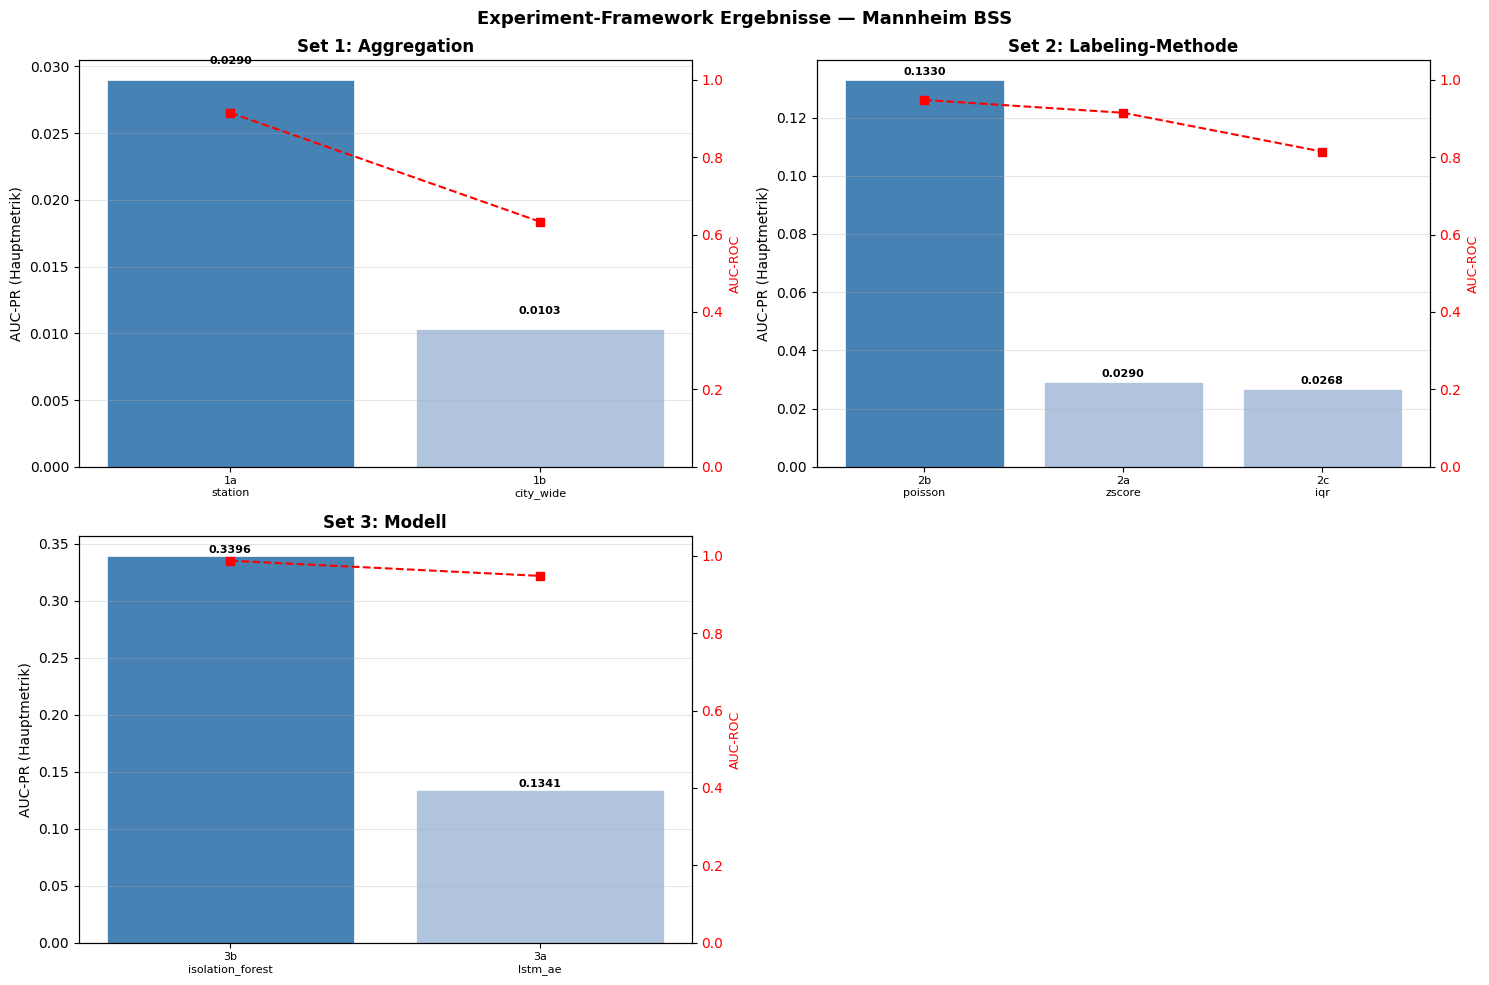

✅ Plot gespeichert: /content/data/experiment_plots/experiment_results_overview.png


In [36]:
# ══════════════════════════════════════════════════════════════
# 14 — Ergebnistabelle & Visualisierung
# ══════════════════════════════════════════════════════════════

results_df = pd.read_csv(RESULTS_LOG)

print('\n' + '='*75)
print('GESAMTERGEBNISSE ALLER RUNS')
print('='*75)
cols_show = ['run_id','experiment_set','aggregation','labeling',
             'model','scoring','auc_pr','f1','auc_roc','anomaly_rate']
print(results_df[cols_show].sort_values('auc_pr', ascending=False).to_string(index=False))

# ── Subplots: Ergebnisse pro Set ──
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Experiment-Framework Ergebnisse — Mannheim BSS', fontsize=13, fontweight='bold')

sets_info = [
    ('Set1_Aggregation', 'aggregation',   'Set 1: Aggregation'),
    ('Set2_Labeling',    'labeling',      'Set 2: Labeling-Methode'),
    ('Set3_Model',       'model',         'Set 3: Modell'),
    ('Set4_Scoring',     'scoring',       'Set 4: Scoring-Funktion'),
]

for ax, (set_name, label_col, title) in zip(axes.flatten(), sets_info):
    subset = results_df[results_df['experiment_set'] == set_name].copy()
    if len(subset) == 0:
        ax.set_visible(False)
        continue

    subset = subset.sort_values('auc_pr', ascending=False)
    x      = range(len(subset))
    labels = [f"{row['run_id']}\n{row[label_col]}" for _, row in subset.iterrows()]

    bars = ax.bar(x, subset['auc_pr'], color=['steelblue' if i == 0 else 'lightsteelblue'
                                               for i in range(len(subset))],
                  edgecolor='white', linewidth=0.5)
    ax2 = ax.twinx()
    ax2.plot(x, subset['auc_roc'], 'rs--', markersize=6, lw=1.5, label='AUC-ROC')
    ax2.set_ylabel('AUC-ROC', color='red', fontsize=9)
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_ylim(0, 1.05)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel('AUC-PR (Hauptmetrik)')
    ax.set_title(title, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')

    # Werte beschriften
    for bar, auc_pr_val in zip(bars, subset['auc_pr']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{auc_pr_val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/experiment_results_overview.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'✅ Plot gespeichert: {PLOTS_DIR}/experiment_results_overview.png')

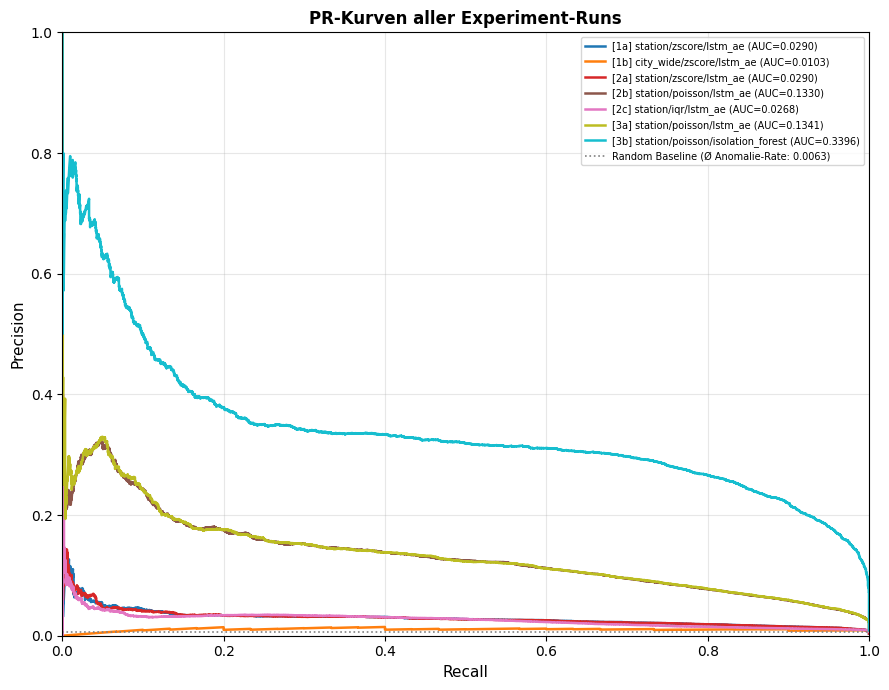

✅ PR-Kurven gespeichert.


In [37]:
# ══════════════════════════════════════════════════════════════
# 15 — PR-Kurven aller Runs im Vergleich
# ══════════════════════════════════════════════════════════════
from sklearn.metrics import precision_recall_curve, auc as sk_auc

completed_runs = {k: v for k, v in results_all.items()
                  if 'error' not in v and '_scores_test' in v}

fig, ax = plt.subplots(figsize=(9, 7))
colors = plt.cm.tab10(np.linspace(0, 1, len(completed_runs)))

for (run_id, res), color in zip(completed_runs.items(), colors):
    binary = (res['_y_test'] == 'anomal').astype(int)
    if binary.sum() == 0:
        continue
    prec, rec, _ = precision_recall_curve(binary, res['_scores_test'])
    auc_pr = sk_auc(rec, prec)
    cfg_obj = next(e for e in EXPERIMENTS if e.run_id == run_id)
    label = f'[{run_id}] {cfg_obj.aggregation}/{cfg_obj.labeling}/{cfg_obj.model} (AUC={auc_pr:.4f})'
    ax.plot(rec, prec, lw=1.8, color=color, label=label)

# Chance-Level (Anomalie-Rate)
baseline_rate = results_df['anomaly_rate'].mean()
ax.axhline(baseline_rate, color='gray', ls=':', lw=1.2,
           label=f'Random Baseline (Ø Anomalie-Rate: {baseline_rate:.4f})')

ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('PR-Kurven aller Experiment-Runs', fontsize=12, fontweight='bold')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.legend(fontsize=7, loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/pr_curves_all_runs.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ PR-Kurven gespeichert.')

In [38]:
# ══════════════════════════════════════════════════════════════
# 16 — Finale Konfiguration für Cross-City Transfer
# ══════════════════════════════════════════════════════════════

best_run_id = results_df.loc[results_df['auc_pr'].idxmax(), 'run_id']
best_run    = results_df[results_df['run_id'] == best_run_id].iloc[0]

print('='*65)
print('BESTE KONFIGURATION — Basis für Cross-City Transfer (Phase 4)')
print('='*65)
print(f'  Run ID:       {best_run["run_id"]}')
print(f'  Aggregation:  {best_run["aggregation"]}')
print(f'  Labeling:     {best_run["labeling"]}')
print(f'  Modell:       {best_run["model"]}')
print(f'  Scoring:      {best_run["scoring"]}')
print(f'  AUC-PR:       {best_run["auc_pr"]:.4f}')
print(f'  AUC-ROC:      {best_run["auc_roc"]:.4f}')
print(f'  F1:           {best_run["f1"]:.4f}')
print(f'  Anomalie-Rate:{best_run["anomaly_rate"]:.4f}')

# Als JSON für Phase 4 speichern
best_config_path = '/content/data/best_config_for_transfer.json'
best_config_dict = {
    'run_id':       best_run['run_id'],
    'aggregation':  best_run['aggregation'],
    'labeling':     best_run['labeling'],
    'model':        best_run['model'],
    'scoring':      best_run['scoring'],
    'auc_pr':       float(best_run['auc_pr']),
    'auc_roc':      float(best_run['auc_roc']),
    'f1':           float(best_run['f1']),
    'source_city':  CITY,
}
with open(best_config_path, 'w') as f:
    json.dump(best_config_dict, f, indent=2)

print(f'\n✅ Gespeichert: {best_config_path}')
print(f'✅ Alle Ergebnisse: {RESULTS_LOG}')
print(f'\n→ Nächster Schritt: Phase 4 — Cross-City Transfer mit dieser Config')

BESTE KONFIGURATION — Basis für Cross-City Transfer (Phase 4)
  Run ID:       3b
  Aggregation:  station
  Labeling:     poisson
  Modell:       isolation_forest
  Scoring:      mse
  AUC-PR:       0.3396
  AUC-ROC:      0.9870
  F1:           0.4057
  Anomalie-Rate:0.0085

✅ Gespeichert: /content/data/best_config_for_transfer.json
✅ Alle Ergebnisse: /content/data/results_log.csv

→ Nächster Schritt: Phase 4 — Cross-City Transfer mit dieser Config



# 17 — V8.2: AE-Fairness, lückenlose Sequenzen und Transfer-Learning-geeignete DL-Tests

Dieses Zusatzset erweitert das bestehende Framework um gezielte **Sanity Checks** und **DL-fokussierte Anschlussversuche**:

1. **Mehr Trainingsbudget für den AE** statt den iForest künstlich zu beschneiden  
2. **Lückenlose Sequenzen** (`require_contiguous=True`), damit der LSTM keine „falschen“ Zeitreihen aus Zeilen mit Stundenlücken lernt  
3. **Minimal-Features** als transfer-robustere Variante  
4. **LSTM-Next-Step-Forecaster** als DL-Alternative, die inhaltlich besser zu Demand-Anomalien und späterem Cross-City Transfer passt

Interpretation:
- Wenn der AE mit mehr Budget und sauberen Sequenzen deutlich aufholt, war der ursprüngliche Vergleich teilweise budget-/designgetrieben.
- Wenn der Forecaster stark ist, spricht das dafür, dass **Residual-basierte sequenzielle Vorhersage** besser zu deinem Zielproblem passt als reine Rekonstruktion.



In [12]:

# ══════════════════════════════════════════════════════════════
# 18 — Zusatz-Helfer für faire AE-Tests & Forecasting
# ══════════════════════════════════════════════════════════════

from dataclasses import replace

# Reproduzierbarkeit
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


class LSTMForecaster(nn.Module):
    """
    Sequenzmodell für Next-Step-Prognose von total_demand.
    Output: 1 Wert pro Sequenz (= Nachfrage im nächsten Zeitschritt).
    """
    def __init__(self, n_features: int, hidden_dim: int = 64, n_layers: int = 2, dropout: float = 0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        return self.head(last).squeeze(-1)


def build_sequences_for_group(df_group: pd.DataFrame,
                              feature_cols: list,
                              window: int,
                              is_lstm: bool = True,
                              require_contiguous: bool = False,
                              target_col: str = None,
                              label_col: str = 'label'):
    """
    Baut Sequenzen aus EINER Zeitreihe.
    Falls require_contiguous=True, werden nur Fenster mit exakt stündlicher Folge verwendet.
    Optional kann ein target_col für Forecasting mit zurückgegeben werden.
    """
    df_group = df_group.sort_values('hour_ts').reset_index(drop=True)
    values = df_group[feature_cols].values.astype(np.float32)
    labels = df_group[label_col].values if label_col in df_group.columns else None
    times  = df_group['hour_ts'].values

    X_list, y_label_list, y_target_list, end_time_list = [], [], [], []

    # AE: Endindex ist inklusive; Forecasting: nächster Zeitschritt ist Target
    end_max = len(df_group) if target_col is None else len(df_group) - 1

    for end_idx in range(window - 1, end_max):
        start_idx = end_idx - window + 1
        seq_times = pd.to_datetime(times[start_idx:end_idx+1])

        if require_contiguous:
            diffs = np.diff(seq_times).astype('timedelta64[h]').astype(int)
            if len(diffs) and not np.all(diffs == 1):
                continue

        seq = values[start_idx:end_idx+1]
        if is_lstm:
            X_list.append(seq)
        else:
            X_list.append(seq.reshape(-1))

        if labels is not None:
            y_label_list.append(labels[end_idx])

        if target_col is not None:
            y_target_list.append(float(df_group[target_col].iloc[end_idx + 1]))

        end_time_list.append(df_group['hour_ts'].iloc[end_idx])

    if len(X_list) == 0:
        X_shape = (0, window, len(feature_cols)) if is_lstm else (0, window * len(feature_cols))
        X = np.empty(X_shape, dtype=np.float32)
    else:
        X = np.stack(X_list).astype(np.float32)

    labels_arr = np.array(y_label_list) if len(y_label_list) else np.array([])
    targets_arr = np.array(y_target_list, dtype=np.float32) if len(y_target_list) else np.array([])
    end_times = np.array(end_time_list)

    return X, labels_arr, targets_arr, end_times


def collect_station_sequences(df_part: pd.DataFrame,
                              feature_cols: list,
                              window: int,
                              is_lstm: bool = True,
                              require_contiguous: bool = False,
                              target_col: str = None):
    """
    Sammeln von Sequenzen stationweise. Verhindert, dass Fenster Stationsgrenzen überschreiten.
    """
    X_all, y_labels_all, y_targets_all, station_ids_all, end_times_all = [], [], [], [], []

    for sid in df_part['station_id'].unique():
        grp = df_part[df_part['station_id'] == sid].copy()
        X, y_lab, y_tar, end_times = build_sequences_for_group(
            grp, feature_cols=feature_cols, window=window, is_lstm=is_lstm,
            require_contiguous=require_contiguous, target_col=target_col, label_col='label'
        )
        if len(X) == 0:
            continue
        X_all.append(X)
        y_labels_all.append(y_lab)
        if target_col is not None:
            y_targets_all.append(y_tar)
        station_ids_all.extend([sid] * len(X))
        end_times_all.extend(list(end_times))

    if len(X_all) == 0:
        X_shape = (0, window, len(feature_cols)) if is_lstm else (0, window * len(feature_cols))
        X = np.empty(X_shape, dtype=np.float32)
    else:
        X = np.concatenate(X_all, axis=0)

    y_labels = np.concatenate(y_labels_all, axis=0) if len(y_labels_all) else np.array([])
    y_targets = np.concatenate(y_targets_all, axis=0) if len(y_targets_all) else np.array([], dtype=np.float32)
    station_ids = np.array(station_ids_all)
    end_times = np.array(end_times_all)

    return X, y_labels, y_targets, station_ids, end_times


def stratified_cap_sequences(X, y_labels, max_items, seed=42):
    """
    Begrenzung großer Val-Sets, ohne seltene Anomalien zu verlieren.
    """
    if len(X) <= max_items:
        return X, y_labels
    rng = np.random.default_rng(seed)
    anom_idx = np.where(y_labels == 'anomal')[0]
    other_idx = np.where(y_labels != 'anomal')[0]
    n_other = min(max_items - len(anom_idx), len(other_idx))
    keep = np.concatenate([anom_idx, rng.choice(other_idx, size=n_other, replace=False)])
    keep = np.sort(keep)
    return X[keep], y_labels[keep]


def train_forecaster(model, X_train, y_train, X_val, y_val,
                     model_name='LSTM_Forecaster',
                     epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LEARNING_RATE,
                     patience=EARLY_STOP, val_chunk=2048):
    """
    Trainiert Next-Step-Regressor mit Huber Loss (robuster gegen Peaks).
    """
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    criterion = nn.HuberLoss(delta=1.0)

    X_t = torch.FloatTensor(X_train)
    y_t = torch.FloatTensor(y_train)
    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=True)

    X_v = torch.FloatTensor(X_val)
    y_v = torch.FloatTensor(y_val)

    best_val, best_state, patience_counter = float('inf'), None, 0

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()
            preds = model(batch_x)
            loss = criterion(preds, batch_y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for i in range(0, len(X_v), val_chunk):
                xb = X_v[i:i+val_chunk].to(device)
                yb = y_v[i:i+val_chunk].to(device)
                val_losses.append(criterion(model(xb), yb).item())
                del xb, yb
        val_loss = float(np.mean(val_losses)) if len(val_losses) else float('inf')
        scheduler.step(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 10 == 0:
            print(f'  [{model_name}] Epoch {epoch+1:3d} | Train: {np.mean(train_losses):.5f} | Val: {val_loss:.5f}')
        if patience_counter >= patience:
            print(f'  [{model_name}] Early stop @ epoch {epoch+1}')
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    model = model.to(device)
    print(f'  [{model_name}] Best Val Loss: {best_val:.6f}')
    return model


def compute_forecast_scores(model, X, y_true, chunk_size=2048, mode='abs'):
    """
    Residual-basierter Anomalie-Score aus Next-Step-Vorhersage.
    mode='abs' oder 'sq'
    """
    model.eval()
    model = model.to(device)
    all_scores = []

    for i in range(0, len(X), chunk_size):
        xb = torch.FloatTensor(X[i:i+chunk_size]).to(device)
        yb = torch.FloatTensor(y_true[i:i+chunk_size]).to(device)
        with torch.no_grad():
            preds = model(xb)
        if mode == 'sq':
            score = (preds - yb) ** 2
        else:
            score = (preds - yb).abs()
        all_scores.append(score.detach().cpu())
        del xb, yb
        torch.cuda.empty_cache()

    return torch.cat(all_scores).numpy() if len(all_scores) else np.array([])


print('Zusatz-Helfer definiert: LSTMForecaster, lückenlose Sequenzen, faire AE-Sammler.')


Zusatz-Helfer definiert: LSTMForecaster, lückenlose Sequenzen, faire AE-Sammler.


In [15]:

# ══════════════════════════════════════════════════════════════
# 19 — Faire AE-Budget- und Sequenz-Checks
# ══════════════════════════════════════════════════════════════

def run_ae_budget_sanity(cfg: ExperimentConfig,
                         hourly_raw: pd.DataFrame,
                         max_train_seqs: int = 50_000,
                         max_val_seqs: int = 15_000,
                         require_contiguous: bool = False,
                         train_on_minimal_features: bool = False,
                         random_seed: int = 42):
    """
    Ziel:
    - gleicher Pipeline-Kern wie run_experiment
    - aber mit explizitem AE-Datenbudget und optional lückenlosen Fenstern
    """
    print(f'\n{"="*70}')
    print(f'AE SANITY [{cfg.run_id}] | budget={max_train_seqs:,} | contiguous={require_contiguous} | '
          f'feature_set={"minimal" if train_on_minimal_features else cfg.feature_set}')
    print(f'{"="*70}')

    np.random.seed(random_seed)
    torch.manual_seed(random_seed)

    local_cfg = replace(cfg)
    if train_on_minimal_features:
        local_cfg.feature_set = 'minimal'

    # 1) Daten
    if local_cfg.aggregation == 'city_wide':
        raise ValueError('Sanity-Block ist auf station-level ausgerichtet. Bitte station-level verwenden.')
    df = build_station_level(hourly_raw, local_cfg)
    feature_cols = [c for c in get_feature_cols(local_cfg) if c in df.columns]
    demand_indices = [i for i, c in enumerate(feature_cols)
                      if c in ('total_demand', 'n_lends', 'n_returns',
                               'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h')]
    print(f'Features: {len(feature_cols)} | Zeilen: {len(df):,} | Stationen: {df["station_id"].nunique()}')

    # 2) Temporal Split + Labels
    t_min, t_max = df['hour_ts'].min(), df['hour_ts'].max()
    total_h = (t_max - t_min).total_seconds() / 3600
    train_end = t_min + pd.Timedelta(hours=int(total_h * TRAIN_RATIO))
    val_end   = t_min + pd.Timedelta(hours=int(total_h * VAL_RATIO))

    df = compute_labels(df, train_end, local_cfg, group_col='station_id')
    anomaly_rate = (df['label'] == 'anomal').mean()
    print(f'Labels: {df["label"].value_counts().to_dict()} | Anomalie-Rate: {anomaly_rate:.4f}')

    df_train = df[(df['hour_ts'] < train_end) & (df['label'] == 'normal')].copy()
    df_val   = df[(df['hour_ts'] >= train_end) & (df['hour_ts'] < val_end) & (df['label'] != 'grauzone')].copy()
    df_test  = df[(df['hour_ts'] >= val_end) & (df['label'] != 'grauzone')].copy()

    print(f'Train normal: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')

    scaler = StandardScaler()
    df_train[feature_cols] = scaler.fit_transform(df_train[feature_cols].values)
    df_val[feature_cols]   = scaler.transform(df_val[feature_cols].values)
    df_test[feature_cols]  = scaler.transform(df_test[feature_cols].values)

    W = local_cfg.window_size

    # 3) Sequenzen sammeln
    X_train, y_train_labels, _, _, _ = collect_station_sequences(
        df_train, feature_cols=feature_cols, window=W, is_lstm=(local_cfg.model == 'lstm_ae'),
        require_contiguous=require_contiguous, target_col=None
    )
    X_val, y_val, _, _, _ = collect_station_sequences(
        df_val, feature_cols=feature_cols, window=W, is_lstm=(local_cfg.model == 'lstm_ae'),
        require_contiguous=require_contiguous, target_col=None
    )
    X_test, y_test, _, _, _ = collect_station_sequences(
        df_test, feature_cols=feature_cols, window=W, is_lstm=(local_cfg.model == 'lstm_ae'),
        require_contiguous=require_contiguous, target_col=None
    )

    print(f'Raw Seq Shapes | Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

    if len(X_train) == 0 or len(X_val) == 0 or len(X_test) == 0:
        raise ValueError('Mindestens ein Split hat 0 Sequenzen. Prüfe window_size / contiguous.')

    rng = np.random.default_rng(random_seed)
    if len(X_train) > max_train_seqs:
        keep = rng.choice(len(X_train), size=max_train_seqs, replace=False)
        X_train = X_train[keep]
    X_val, y_val = stratified_cap_sequences(X_val, y_val, max_val_seqs, seed=random_seed)

    print(f'Used Seq Shapes | Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')
    print(f'Val anomal: {(y_val=="anomal").sum()} | Test anomal: {(y_test=="anomal").sum()}')

    # 4) Modell
    n_features = len(feature_cols)
    if local_cfg.model == 'lstm_ae':
        model = LSTMAutoencoder(n_features=n_features, latent_dim=LATENT_DIM)
    else:
        model = VanillaAE(input_dim=W * n_features, latent_dim=LATENT_DIM)

    print(f'Parameter: {sum(p.numel() for p in model.parameters()):,}')
    model = train_ae(model, X_train, X_val, model_name=f'{local_cfg.model.upper()}_SANITY')

    # 5) Scores + Eval
    scores_val = compute_ae_scores(
        model, X_val, scoring=local_cfg.scoring, demand_indices=demand_indices,
        window_size=W, n_features=n_features
    )
    scores_test = compute_ae_scores(
        model, X_test, scoring=local_cfg.scoring, demand_indices=demand_indices,
        window_size=W, n_features=n_features
    )

    threshold, best_val_f1 = find_best_threshold(scores_val, y_val)
    binary_test = (y_test == 'anomal').astype(int)
    preds_test = (scores_test > threshold).astype(int)

    prec, rec, _ = precision_recall_curve(binary_test, scores_test)
    auc_pr = auc(rec, prec)
    f1 = f1_score(binary_test, preds_test, zero_division=0)
    auc_roc = roc_auc_score(binary_test, scores_test) if len(np.unique(binary_test)) > 1 else 0.0

    out = {
        'run_id': cfg.run_id,
        'budget_train_seqs': int(max_train_seqs),
        'budget_val_seqs': int(max_val_seqs),
        'require_contiguous': bool(require_contiguous),
        'feature_set': local_cfg.feature_set,
        'model': local_cfg.model,
        'labeling': local_cfg.labeling,
        'scoring': local_cfg.scoring,
        'auc_pr': float(auc_pr),
        'f1': float(f1),
        'auc_roc': float(auc_roc),
        'threshold': float(threshold),
        'best_val_f1': float(best_val_f1),
        'anomaly_rate': float(anomaly_rate),
        'n_test': int(len(binary_test)),
        'n_anomalies_test': int(binary_test.sum()),
        '_scores_test': scores_test,
        '_y_test': y_test
    }
    print(f'▶ SANITY RESULT | AUC-PR: {auc_pr:.4f} | F1: {f1:.4f} | AUC-ROC: {auc_roc:.4f}')
    return out


# Basiskonfiguration: strongest AE-compatible setting aus den bisherigen Ergebnissen
cfg_poisson_lstm = ExperimentConfig(
    run_id='v82_ae_base',
    description='V8.2 AE Sanity Base',
    experiment_set='V82_AE_Sanity',
    aggregation='station',
    labeling='poisson',
    model='lstm_ae',
    scoring='mse',
    feature_set='base'
)

ae_sanity_results = []

ae_sanity_plan = [
    dict(run_id='v82_ae_50k_orig',  max_train_seqs=50_000,  max_val_seqs=15_000,
         require_contiguous=False, train_on_minimal_features=False),
    dict(run_id='v82_ae_200k',      max_train_seqs=200_000, max_val_seqs=40_000,
         require_contiguous=False, train_on_minimal_features=False),
    dict(run_id='v82_ae_200k_cont', max_train_seqs=200_000, max_val_seqs=40_000,
         require_contiguous=True,  train_on_minimal_features=False),
    dict(run_id='v82_ae_200k_cont_minfeat', max_train_seqs=200_000, max_val_seqs=40_000,
         require_contiguous=True,  train_on_minimal_features=True),
]

for plan in ae_sanity_plan:
    cfg_local = replace(cfg_poisson_lstm, run_id=plan['run_id'], feature_set='base')
    try:
        res = run_ae_budget_sanity(
            cfg_local, hourly_raw,
            max_train_seqs=plan['max_train_seqs'],
            max_val_seqs=plan['max_val_seqs'],
            require_contiguous=plan['require_contiguous'],
            train_on_minimal_features=plan['train_on_minimal_features']
        )
        ae_sanity_results.append(res)
    except Exception as e:
        print(f'❌ {plan["run_id"]} fehlgeschlagen: {e}')

ae_sanity_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in ae_sanity_results])
display(ae_sanity_df.sort_values('auc_pr', ascending=False))



AE SANITY [v82_ae_50k_orig] | budget=50,000 | contiguous=False | feature_set=base
Features: 19 | Zeilen: 2,179,672 | Stationen: 88
Labels: {'normal': 2051600, 'grauzone': 109477, 'anomal': 18595} | Anomalie-Rate: 0.0085
Train normal: 1,380,904 | Val: 325,082 | Test: 352,534
Raw Seq Shapes | Train: (1378880, 24, 19) | Val: (323058, 24, 19) | Test: (350510, 24, 19)
Used Seq Shapes | Train: (50000, 24, 19) | Val: (15000, 24, 19) | Test: (350510, 24, 19)
Val anomal: 3746 | Test anomal: 3151
Parameter: 32,755
  [LSTM_AE_SANITY] Epoch  10 | Train: 0.39501 | Val: 1.04078
  [LSTM_AE_SANITY] Epoch  20 | Train: 0.29187 | Val: 0.84407
  [LSTM_AE_SANITY] Epoch  30 | Train: 0.26320 | Val: 0.77182
  [LSTM_AE_SANITY] Epoch  40 | Train: 0.24850 | Val: 0.72902
  [LSTM_AE_SANITY] Epoch  50 | Train: 0.23808 | Val: 0.70307
  [LSTM_AE_SANITY] Best Val Loss: 0.703066
▶ SANITY RESULT | AUC-PR: 0.1341 | F1: 0.1183 | AUC-ROC: 0.9481

AE SANITY [v82_ae_200k] | budget=200,000 | contiguous=False | feature_set=ba

,run_id,budget_train_seqs,budget_val_seqs,require_contiguous,feature_set,model,labeling,scoring,auc_pr,f1,auc_roc,threshold,best_val_f1,anomaly_rate,n_test,n_anomalies_test
0,v82_ae_50k_orig,50000,15000,False,base,lstm_ae,poisson,mse,0.134090,0.118255,0.948123,1.010441,0.731239,0.008531,350510,3151
1,v82_ae_200k,200000,40000,False,base,lstm_ae,poisson,mse,0.133768,0.161091,0.944928,1.459283,0.535839,0.008531,350510,3151
3,v82_ae_200k_cont_minfeat,200000,40000,True,minimal,lstm_ae,poisson,mse,0.068567,0.115124,0.953509,2.925307,0.194958,0.008531,163617,327
2,v82_ae_200k_cont,200000,40000,True,base,lstm_ae,poisson,mse,0.061617,0.135198,0.961037,4.746110,0.188100,0.008531,163617,327


In [17]:

# ══════════════════════════════════════════════════════════════
# 20 — DL-Alternative für Transfer Learning: LSTM Next-Step Forecasting
# ══════════════════════════════════════════════════════════════

def run_lstm_forecasting_experiment(cfg: ExperimentConfig,
                                    hourly_raw: pd.DataFrame,
                                    max_train_seqs: int = 200_000,
                                    max_val_seqs: int = 40_000,
                                    require_contiguous: bool = True,
                                    score_mode: str = 'abs',
                                    random_seed: int = 42):
    """
    Forecasting statt Rekonstruktion:
    - Input: letzte W Stunden Features
    - Target: total_demand im nächsten Zeitschritt
    - Score: Residuum |y - y_hat|
    """
    print(f'\n{"="*70}')
    print(f'FORECAST SANITY [{cfg.run_id}] | budget={max_train_seqs:,} | contiguous={require_contiguous} | '
          f'feature_set={cfg.feature_set}')
    print(f'{"="*70}')

    np.random.seed(random_seed)
    torch.manual_seed(random_seed)

    if cfg.aggregation != 'station':
        raise ValueError('Forecast-Block ist für station-level ausgelegt.')

    # 1) Daten & Labels
    df = build_station_level(hourly_raw, cfg)
    feature_cols = [c for c in get_feature_cols(cfg) if c in df.columns]

    t_min, t_max = df['hour_ts'].min(), df['hour_ts'].max()
    total_h = (t_max - t_min).total_seconds() / 3600
    train_end = t_min + pd.Timedelta(hours=int(total_h * TRAIN_RATIO))
    val_end   = t_min + pd.Timedelta(hours=int(total_h * VAL_RATIO))

    df = compute_labels(df, train_end, cfg, group_col='station_id')
    anomaly_rate = (df['label'] == 'anomal').mean()

    # Training weiterhin nur auf normalen Zeitpunkten
    df_train = df[(df['hour_ts'] < train_end) & (df['label'] == 'normal')].copy()
    df_val   = df[(df['hour_ts'] >= train_end) & (df['hour_ts'] < val_end) & (df['label'] != 'grauzone')].copy()
    df_test  = df[(df['hour_ts'] >= val_end) & (df['label'] != 'grauzone')].copy()

    scaler = StandardScaler()
    df_train[feature_cols] = scaler.fit_transform(df_train[feature_cols].values)
    df_val[feature_cols]   = scaler.transform(df_val[feature_cols].values)
    df_test[feature_cols]  = scaler.transform(df_test[feature_cols].values)

    W = cfg.window_size

    X_train, _, y_train_target, _, _ = collect_station_sequences(
        df_train, feature_cols=feature_cols, window=W, is_lstm=True,
        require_contiguous=require_contiguous, target_col='total_demand'
    )
    X_val, y_val_labels, y_val_target, _, _ = collect_station_sequences(
        df_val, feature_cols=feature_cols, window=W, is_lstm=True,
        require_contiguous=require_contiguous, target_col='total_demand'
    )
    X_test, y_test_labels, y_test_target, _, _ = collect_station_sequences(
        df_test, feature_cols=feature_cols, window=W, is_lstm=True,
        require_contiguous=require_contiguous, target_col='total_demand'
    )

    print(f'Raw Seq Shapes | Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

    if len(X_train) == 0 or len(X_val) == 0 or len(X_test) == 0:
        raise ValueError('Mindestens ein Split hat 0 Forecast-Sequenzen.')

    rng = np.random.default_rng(random_seed)
    if len(X_train) > max_train_seqs:
        keep = rng.choice(len(X_train), size=max_train_seqs, replace=False)
        X_train, y_train_target = X_train[keep], y_train_target[keep]

    if len(X_val) > max_val_seqs:
        anom_idx = np.where(y_val_labels == 'anomal')[0]
        rest_idx = np.where(y_val_labels != 'anomal')[0]
        n_rest = min(max_val_seqs - len(anom_idx), len(rest_idx))
        keep = np.concatenate([anom_idx, rng.choice(rest_idx, size=n_rest, replace=False)])
        keep = np.sort(keep)
        X_val, y_val_labels, y_val_target = X_val[keep], y_val_labels[keep], y_val_target[keep]

    print(f'Used Seq Shapes | Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')
    print(f'Val anomal: {(y_val_labels=="anomal").sum()} | Test anomal: {(y_test_labels=="anomal").sum()}')

    model = LSTMForecaster(n_features=len(feature_cols), hidden_dim=64, n_layers=2, dropout=0.1)
    print(f'Parameter: {sum(p.numel() for p in model.parameters()):,}')
    model = train_forecaster(
        model, X_train, y_train_target, X_val, y_val_target,
        model_name='LSTM_FORECAST'
    )

    scores_val = compute_forecast_scores(model, X_val, y_val_target, mode=score_mode)
    scores_test = compute_forecast_scores(model, X_test, y_test_target, mode=score_mode)

    threshold, best_val_f1 = find_best_threshold(scores_val, y_val_labels)
    binary_test = (y_test_labels == 'anomal').astype(int)
    preds_test = (scores_test > threshold).astype(int)

    prec, rec, _ = precision_recall_curve(binary_test, scores_test)
    auc_pr = auc(rec, prec)
    f1 = f1_score(binary_test, preds_test, zero_division=0)
    auc_roc = roc_auc_score(binary_test, scores_test) if len(np.unique(binary_test)) > 1 else 0.0

    res = {
        'run_id': cfg.run_id,
        'model': 'lstm_forecaster',
        'feature_set': cfg.feature_set,
        'labeling': cfg.labeling,
        'score_mode': score_mode,
        'require_contiguous': require_contiguous,
        'budget_train_seqs': int(max_train_seqs),
        'auc_pr': float(auc_pr),
        'f1': float(f1),
        'auc_roc': float(auc_roc),
        'threshold': float(threshold),
        'best_val_f1': float(best_val_f1),
        'anomaly_rate': float(anomaly_rate),
        'n_test': int(len(binary_test)),
        'n_anomalies_test': int(binary_test.sum()),
        '_scores_test': scores_test,
        '_y_test': y_test_labels
    }
    print(f'▶ FORECAST RESULT | AUC-PR: {auc_pr:.4f} | F1: {f1:.4f} | AUC-ROC: {auc_roc:.4f}')
    return res


forecast_cfgs = [
    ExperimentConfig(
        run_id='v82_forecast_base',
        description='LSTM forecast with base features',
        experiment_set='V82_Forecast',
        aggregation='station',
        labeling='poisson',
        feature_set='base',
        model='lstm_ae',
        scoring='mse'
    ),
    ExperimentConfig(
        run_id='v82_forecast_minimal',
        description='LSTM forecast with minimal transfer-robust features',
        experiment_set='V82_Forecast',
        aggregation='station',
        labeling='poisson',
        feature_set='minimal',
        model='lstm_ae',
        scoring='mse'
    ),
]

forecast_results = []
for cfg in forecast_cfgs:
    try:
        forecast_results.append(
            run_lstm_forecasting_experiment(
                cfg, hourly_raw,
                max_train_seqs=200_000,
                max_val_seqs=40_000,
                require_contiguous=True,
                score_mode='abs'
            )
        )
    except Exception as e:
        print(f'❌ {cfg.run_id} fehlgeschlagen: {e}')

forecast_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in forecast_results])
display(forecast_df.sort_values('auc_pr', ascending=False))



FORECAST SANITY [v82_forecast_base] | budget=200,000 | contiguous=True | feature_set=base
Raw Seq Shapes | Train: (655043, 24, 19) | Val: (104631, 24, 19) | Test: (163574, 24, 19)
Used Seq Shapes | Train: (200000, 24, 19) | Val: (40000, 24, 19) | Test: (163574, 24, 19)
Val anomal: 273 | Test anomal: 327
Parameter: 59,265
  [LSTM_FORECAST] Epoch  10 | Train: 0.08977 | Val: 0.13798
  [LSTM_FORECAST] Epoch  20 | Train: 0.08655 | Val: 0.13626
  [LSTM_FORECAST] Epoch  30 | Train: 0.08433 | Val: 0.13643
  [LSTM_FORECAST] Early stop @ epoch 33
  [LSTM_FORECAST] Best Val Loss: 0.136157
▶ FORECAST RESULT | AUC-PR: 0.0443 | F1: 0.1005 | AUC-ROC: 0.8394

FORECAST SANITY [v82_forecast_minimal] | budget=200,000 | contiguous=True | feature_set=minimal


KeyboardInterrupt: 

In [19]:

# ══════════════════════════════════════════════════════════════
# 20 — DL-Alternative für Transfer Learning: LSTM Next-Step Forecasting
# ══════════════════════════════════════════════════════════════

def run_lstm_forecasting_experiment(cfg: ExperimentConfig,
                                    hourly_raw: pd.DataFrame,
                                    max_train_seqs: int = 50_000,
                                    max_val_seqs: int = 40_000,
                                    require_contiguous: bool = False,
                                    score_mode: str = 'abs',
                                    random_seed: int = 42):
    """
    Forecasting statt Rekonstruktion:
    - Input: letzte W Stunden Features
    - Target: total_demand im nächsten Zeitschritt
    - Score: Residuum |y - y_hat|
    """
    print(f'\n{"="*70}')
    print(f'FORECAST SANITY [{cfg.run_id}] | budget={max_train_seqs:,} | contiguous={require_contiguous} | '
          f'feature_set={cfg.feature_set}')
    print(f'{"="*70}')

    np.random.seed(random_seed)
    torch.manual_seed(random_seed)

    if cfg.aggregation != 'station':
        raise ValueError('Forecast-Block ist für station-level ausgelegt.')

    # 1) Daten & Labels
    df = build_station_level(hourly_raw, cfg)
    feature_cols = [c for c in get_feature_cols(cfg) if c in df.columns]

    t_min, t_max = df['hour_ts'].min(), df['hour_ts'].max()
    total_h = (t_max - t_min).total_seconds() / 3600
    train_end = t_min + pd.Timedelta(hours=int(total_h * TRAIN_RATIO))
    val_end   = t_min + pd.Timedelta(hours=int(total_h * VAL_RATIO))

    df = compute_labels(df, train_end, cfg, group_col='station_id')
    anomaly_rate = (df['label'] == 'anomal').mean()

    # Training weiterhin nur auf normalen Zeitpunkten
    df_train = df[(df['hour_ts'] < train_end) & (df['label'] == 'normal')].copy()
    df_val   = df[(df['hour_ts'] >= train_end) & (df['hour_ts'] < val_end) & (df['label'] != 'grauzone')].copy()
    df_test  = df[(df['hour_ts'] >= val_end) & (df['label'] != 'grauzone')].copy()

    scaler = StandardScaler()
    df_train[feature_cols] = scaler.fit_transform(df_train[feature_cols].values)
    df_val[feature_cols]   = scaler.transform(df_val[feature_cols].values)
    df_test[feature_cols]  = scaler.transform(df_test[feature_cols].values)

    W = cfg.window_size

    X_train, _, y_train_target, _, _ = collect_station_sequences(
        df_train, feature_cols=feature_cols, window=W, is_lstm=True,
        require_contiguous=require_contiguous, target_col='total_demand'
    )
    X_val, y_val_labels, y_val_target, _, _ = collect_station_sequences(
        df_val, feature_cols=feature_cols, window=W, is_lstm=True,
        require_contiguous=require_contiguous, target_col='total_demand'
    )
    X_test, y_test_labels, y_test_target, _, _ = collect_station_sequences(
        df_test, feature_cols=feature_cols, window=W, is_lstm=True,
        require_contiguous=require_contiguous, target_col='total_demand'
    )

    print(f'Raw Seq Shapes | Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

    if len(X_train) == 0 or len(X_val) == 0 or len(X_test) == 0:
        raise ValueError('Mindestens ein Split hat 0 Forecast-Sequenzen.')

    rng = np.random.default_rng(random_seed)
    if len(X_train) > max_train_seqs:
        keep = rng.choice(len(X_train), size=max_train_seqs, replace=False)
        X_train, y_train_target = X_train[keep], y_train_target[keep]

    if len(X_val) > max_val_seqs:
        anom_idx = np.where(y_val_labels == 'anomal')[0]
        rest_idx = np.where(y_val_labels != 'anomal')[0]
        n_rest = min(max_val_seqs - len(anom_idx), len(rest_idx))
        keep = np.concatenate([anom_idx, rng.choice(rest_idx, size=n_rest, replace=False)])
        keep = np.sort(keep)
        X_val, y_val_labels, y_val_target = X_val[keep], y_val_labels[keep], y_val_target[keep]

    print(f'Used Seq Shapes | Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')
    print(f'Val anomal: {(y_val_labels=="anomal").sum()} | Test anomal: {(y_test_labels=="anomal").sum()}')

    model = LSTMForecaster(n_features=len(feature_cols), hidden_dim=64, n_layers=2, dropout=0.1)
    print(f'Parameter: {sum(p.numel() for p in model.parameters()):,}')
    model = train_forecaster(
        model, X_train, y_train_target, X_val, y_val_target,
        model_name='LSTM_FORECAST'
    )

    scores_val = compute_forecast_scores(model, X_val, y_val_target, mode=score_mode)
    scores_test = compute_forecast_scores(model, X_test, y_test_target, mode=score_mode)

    threshold, best_val_f1 = find_best_threshold(scores_val, y_val_labels)
    binary_test = (y_test_labels == 'anomal').astype(int)
    preds_test = (scores_test > threshold).astype(int)

    prec, rec, _ = precision_recall_curve(binary_test, scores_test)
    auc_pr = auc(rec, prec)
    f1 = f1_score(binary_test, preds_test, zero_division=0)
    auc_roc = roc_auc_score(binary_test, scores_test) if len(np.unique(binary_test)) > 1 else 0.0

    res = {
        'run_id': cfg.run_id,
        'model': 'lstm_forecaster',
        'feature_set': cfg.feature_set,
        'labeling': cfg.labeling,
        'score_mode': score_mode,
        'require_contiguous': require_contiguous,
        'budget_train_seqs': int(max_train_seqs),
        'auc_pr': float(auc_pr),
        'f1': float(f1),
        'auc_roc': float(auc_roc),
        'threshold': float(threshold),
        'best_val_f1': float(best_val_f1),
        'anomaly_rate': float(anomaly_rate),
        'n_test': int(len(binary_test)),
        'n_anomalies_test': int(binary_test.sum()),
        '_scores_test': scores_test,
        '_y_test': y_test_labels
    }
    print(f'▶ FORECAST RESULT | AUC-PR: {auc_pr:.4f} | F1: {f1:.4f} | AUC-ROC: {auc_roc:.4f}')
    return res


forecast_cfgs = [
    ExperimentConfig(
        run_id='v82_forecast_base',
        description='LSTM forecast with base features',
        experiment_set='V82_Forecast',
        aggregation='station',
        labeling='poisson',
        feature_set='base',
        model='lstm_ae',
        scoring='mse'
    ),
    ExperimentConfig(
        run_id='v82_forecast_minimal',
        description='LSTM forecast with minimal transfer-robust features',
        experiment_set='V82_Forecast',
        aggregation='station',
        labeling='poisson',
        feature_set='minimal',
        model='lstm_ae',
        scoring='mse'
    ),
]

forecast_results = []
for cfg in forecast_cfgs:
    try:
        forecast_results.append(
            run_lstm_forecasting_experiment(
                cfg, hourly_raw,
                max_train_seqs=50_000,
                max_val_seqs=15_000,
                require_contiguous=False,
                score_mode='abs'
            )
        )
    except Exception as e:
        print(f'❌ {cfg.run_id} fehlgeschlagen: {e}')

forecast_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in forecast_results])
display(forecast_df.sort_values('auc_pr', ascending=False))



FORECAST SANITY [v82_forecast_base] | budget=50,000 | contiguous=False | feature_set=base
Raw Seq Shapes | Train: (1378792, 24, 19) | Val: (322970, 24, 19) | Test: (350422, 24, 19)
Used Seq Shapes | Train: (50000, 24, 19) | Val: (15000, 24, 19) | Test: (350422, 24, 19)
Val anomal: 3746 | Test anomal: 3151
Parameter: 59,265
  [LSTM_FORECAST] Epoch  10 | Train: 0.15260 | Val: 0.56696
  [LSTM_FORECAST] Epoch  20 | Train: 0.14617 | Val: 0.58671
  [LSTM_FORECAST] Epoch  30 | Train: 0.13742 | Val: 0.57450
  [LSTM_FORECAST] Early stop @ epoch 30
  [LSTM_FORECAST] Best Val Loss: 0.559907
▶ FORECAST RESULT | AUC-PR: 0.0998 | F1: 0.0985 | AUC-ROC: 0.8691

FORECAST SANITY [v82_forecast_minimal] | budget=50,000 | contiguous=False | feature_set=minimal


KeyboardInterrupt: 

In [22]:

# ══════════════════════════════════════════════════════════════
# 20 — DL-Alternative für Transfer Learning: LSTM Next-Step Forecasting
# ══════════════════════════════════════════════════════════════

def run_lstm_forecasting_experiment(cfg: ExperimentConfig,
                                    hourly_raw: pd.DataFrame,
                                    max_train_seqs: int = 50_000,
                                    max_val_seqs: int = 40_000,
                                    require_contiguous: bool = False,
                                    score_mode: str = 'abs',
                                    random_seed: int = 42):
    """
    Forecasting statt Rekonstruktion:
    - Input: letzte W Stunden Features
    - Target: total_demand im nächsten Zeitschritt
    - Score: Residuum |y - y_hat|
    """
    print(f'\n{"="*70}')
    print(f'FORECAST SANITY [{cfg.run_id}] | budget={max_train_seqs:,} | contiguous={require_contiguous} | '
          f'feature_set={cfg.feature_set}')
    print(f'{"="*70}')

    np.random.seed(random_seed)
    torch.manual_seed(random_seed)

    if cfg.aggregation != 'station':
        raise ValueError('Forecast-Block ist für station-level ausgelegt.')

    # 1) Daten & Labels
    df = build_station_level(hourly_raw, cfg)
    feature_cols = [c for c in get_feature_cols(cfg) if c in df.columns]

    t_min, t_max = df['hour_ts'].min(), df['hour_ts'].max()
    total_h = (t_max - t_min).total_seconds() / 3600
    train_end = t_min + pd.Timedelta(hours=int(total_h * TRAIN_RATIO))
    val_end   = t_min + pd.Timedelta(hours=int(total_h * VAL_RATIO))

    df = compute_labels(df, train_end, cfg, group_col='station_id')
    anomaly_rate = (df['label'] == 'anomal').mean()

    # Training weiterhin nur auf normalen Zeitpunkten
    df_train = df[(df['hour_ts'] < train_end) & (df['label'] == 'normal')].copy()
    df_val   = df[(df['hour_ts'] >= train_end) & (df['hour_ts'] < val_end) & (df['label'] != 'grauzone')].copy()
    df_test  = df[(df['hour_ts'] >= val_end) & (df['label'] != 'grauzone')].copy()

    scaler = StandardScaler()
    df_train[feature_cols] = scaler.fit_transform(df_train[feature_cols].values)
    df_val[feature_cols]   = scaler.transform(df_val[feature_cols].values)
    df_test[feature_cols]  = scaler.transform(df_test[feature_cols].values)

    W = cfg.window_size

    X_train, _, y_train_target, _, _ = collect_station_sequences(
        df_train, feature_cols=feature_cols, window=W, is_lstm=True,
        require_contiguous=require_contiguous, target_col='total_demand'
    )
    X_val, y_val_labels, y_val_target, _, _ = collect_station_sequences(
        df_val, feature_cols=feature_cols, window=W, is_lstm=True,
        require_contiguous=require_contiguous, target_col='total_demand'
    )
    X_test, y_test_labels, y_test_target, _, _ = collect_station_sequences(
        df_test, feature_cols=feature_cols, window=W, is_lstm=True,
        require_contiguous=require_contiguous, target_col='total_demand'
    )

    print(f'Raw Seq Shapes | Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

    if len(X_train) == 0 or len(X_val) == 0 or len(X_test) == 0:
        raise ValueError('Mindestens ein Split hat 0 Forecast-Sequenzen.')

    rng = np.random.default_rng(random_seed)
    if len(X_train) > max_train_seqs:
        keep = rng.choice(len(X_train), size=max_train_seqs, replace=False)
        X_train, y_train_target = X_train[keep], y_train_target[keep]

    if len(X_val) > max_val_seqs:
        anom_idx = np.where(y_val_labels == 'anomal')[0]
        rest_idx = np.where(y_val_labels != 'anomal')[0]
        n_rest = min(max_val_seqs - len(anom_idx), len(rest_idx))
        keep = np.concatenate([anom_idx, rng.choice(rest_idx, size=n_rest, replace=False)])
        keep = np.sort(keep)
        X_val, y_val_labels, y_val_target = X_val[keep], y_val_labels[keep], y_val_target[keep]

    print(f'Used Seq Shapes | Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')
    print(f'Val anomal: {(y_val_labels=="anomal").sum()} | Test anomal: {(y_test_labels=="anomal").sum()}')

    model = LSTMForecaster(n_features=len(feature_cols), hidden_dim=64, n_layers=2, dropout=0.1)
    print(f'Parameter: {sum(p.numel() for p in model.parameters()):,}')
    model = train_forecaster(
        model, X_train, y_train_target, X_val, y_val_target,
        model_name='LSTM_FORECAST'
    )

    scores_val = compute_forecast_scores(model, X_val, y_val_target, mode=score_mode)
    scores_test = compute_forecast_scores(model, X_test, y_test_target, mode=score_mode)

    threshold, best_val_f1 = find_best_threshold(scores_val, y_val_labels)
    binary_test = (y_test_labels == 'anomal').astype(int)
    preds_test = (scores_test > threshold).astype(int)

    prec, rec, _ = precision_recall_curve(binary_test, scores_test)
    auc_pr = auc(rec, prec)
    f1 = f1_score(binary_test, preds_test, zero_division=0)
    auc_roc = roc_auc_score(binary_test, scores_test) if len(np.unique(binary_test)) > 1 else 0.0

    res = {
        'run_id': cfg.run_id,
        'model': 'lstm_forecaster',
        'feature_set': cfg.feature_set,
        'labeling': cfg.labeling,
        'score_mode': score_mode,
        'require_contiguous': require_contiguous,
        'budget_train_seqs': int(max_train_seqs),
        'auc_pr': float(auc_pr),
        'f1': float(f1),
        'auc_roc': float(auc_roc),
        'threshold': float(threshold),
        'best_val_f1': float(best_val_f1),
        'anomaly_rate': float(anomaly_rate),
        'n_test': int(len(binary_test)),
        'n_anomalies_test': int(binary_test.sum()),
        '_scores_test': scores_test,
        '_y_test': y_test_labels
    }
    print(f'▶ FORECAST RESULT | AUC-PR: {auc_pr:.4f} | F1: {f1:.4f} | AUC-ROC: {auc_roc:.4f}')
    return res


forecast_cfgs = [
    ExperimentConfig(
        run_id='v82_forecast_minimal',
        description='LSTM forecast with minimal transfer-robust features',
        experiment_set='V82_Forecast',
        aggregation='station',
        labeling='poisson',
        feature_set='minimal',
        model='lstm_ae',
        scoring='mse'
    ),
]

forecast_results = []
for cfg in forecast_cfgs:
    try:
        forecast_results.append(
            run_lstm_forecasting_experiment(
                cfg, hourly_raw,
                max_train_seqs=50_000,
                max_val_seqs=15_000,
                require_contiguous=False,
                score_mode='abs'
            )
        )
    except Exception as e:
        print(f'❌ {cfg.run_id} fehlgeschlagen: {e}')

forecast_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in forecast_results])
display(forecast_df.sort_values('auc_pr', ascending=False))



FORECAST SANITY [v82_forecast_minimal] | budget=50,000 | contiguous=False | feature_set=minimal
Raw Seq Shapes | Train: (1378792, 24, 15) | Val: (322970, 24, 15) | Test: (350422, 24, 15)
Used Seq Shapes | Train: (50000, 24, 15) | Val: (15000, 24, 15) | Test: (350422, 24, 15)
Val anomal: 3746 | Test anomal: 3151
Parameter: 58,241
  [LSTM_FORECAST] Epoch  10 | Train: 0.15342 | Val: 0.56795
  [LSTM_FORECAST] Epoch  20 | Train: 0.14677 | Val: 0.56072
  [LSTM_FORECAST] Epoch  30 | Train: 0.14273 | Val: 0.56083
  [LSTM_FORECAST] Early stop @ epoch 32
  [LSTM_FORECAST] Best Val Loss: 0.557499
▶ FORECAST RESULT | AUC-PR: 0.0992 | F1: 0.1017 | AUC-ROC: 0.8673


,run_id,model,feature_set,labeling,score_mode,require_contiguous,budget_train_seqs,auc_pr,f1,auc_roc,threshold,best_val_f1,anomaly_rate,n_test,n_anomalies_test
0,v82_forecast_minimal,lstm_forecaster,minimal,poisson,abs,False,50000,0.09925,0.10175,0.867279,0.842258,0.62787,0.008531,350422,3151


V8.2 — KOMPATIBILISIERTE ERGEBNISÜBERSICHT


,run_id,experiment_set,aggregation,labeling,model,scoring,feature_set,auc_pr,f1,auc_roc,anomaly_rate
0,v82_ae_50k_orig,V82_AE_Sanity,station,poisson,lstm_ae,mse,base,0.134090,0.118255,0.948123,0.008531
1,v82_ae_200k,V82_AE_Sanity,station,poisson,lstm_ae,mse,base,0.133768,0.161091,0.944928,0.008531
2,v82_forecast_minimal,V82_Forecast,station,poisson,lstm_forecaster,forecast_abs_residual,minimal,0.099250,0.101750,0.867279,0.008531
3,v82_ae_200k_cont_minfeat,V82_AE_Sanity,station,poisson,lstm_ae,mse,minimal,0.068567,0.115124,0.953509,0.008531
4,v82_ae_200k_cont,V82_AE_Sanity,station,poisson,lstm_ae,mse,base,0.061617,0.135198,0.961037,0.008531


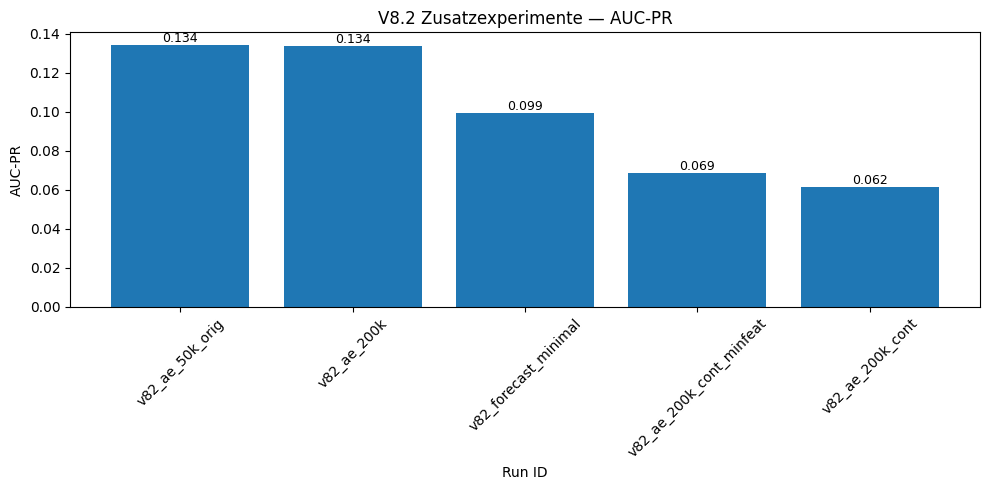


Leselogik:
- Wenn v82_ae_200k oder v82_ae_200k_cont klar über v82_ae_50k_orig liegen,
  war das alte AE-Ergebnis teilweise budget- oder sequenzbedingt.
- Wenn v82_forecast_* den AE schlägt, ist Forecasting die bessere DL-Richtung
  für Demand-Anomalien und spätere Cross-City-Pretrain/Fine-Tune-Setups.



In [23]:

# ══════════════════════════════════════════════════════════════
# 21 — V8.2 Vergleichsübersicht
# ══════════════════════════════════════════════════════════════

rows = []

# Bisherige Framework-Ergebnisse (falls results_df bereits existiert)
if 'results_df' in globals():
    base_cols = ['run_id', 'experiment_set', 'aggregation', 'labeling', 'model', 'scoring', 'feature_set',
                 'auc_pr', 'f1', 'auc_roc', 'anomaly_rate']
    for col in base_cols:
        if col not in results_df.columns:
            results_df[col] = np.nan
    rows.append(results_df[base_cols].copy())

if 'ae_sanity_df' in globals() and len(ae_sanity_df):
    tmp = ae_sanity_df.copy()
    tmp['experiment_set'] = 'V82_AE_Sanity'
    tmp['aggregation'] = 'station'
    tmp['scoring'] = tmp.get('scoring', 'mse')
    for col in ['feature_set', 'auc_pr', 'f1', 'auc_roc', 'anomaly_rate', 'run_id', 'labeling', 'model']:
        if col not in tmp.columns:
            tmp[col] = np.nan
    rows.append(tmp[['run_id', 'experiment_set', 'aggregation', 'labeling', 'model', 'scoring', 'feature_set',
                     'auc_pr', 'f1', 'auc_roc', 'anomaly_rate']])

if 'forecast_df' in globals() and len(forecast_df):
    tmp = forecast_df.copy()
    tmp['experiment_set'] = 'V82_Forecast'
    tmp['aggregation'] = 'station'
    tmp['scoring'] = 'forecast_abs_residual'
    for col in ['feature_set', 'auc_pr', 'f1', 'auc_roc', 'anomaly_rate', 'run_id', 'labeling', 'model']:
        if col not in tmp.columns:
            tmp[col] = np.nan
    rows.append(tmp[['run_id', 'experiment_set', 'aggregation', 'labeling', 'model', 'scoring', 'feature_set',
                     'auc_pr', 'f1', 'auc_roc', 'anomaly_rate']])

v82_compare_df = pd.concat(rows, ignore_index=True)
v82_compare_df = v82_compare_df.sort_values('auc_pr', ascending=False).reset_index(drop=True)

print('=' * 85)
print('V8.2 — KOMPATIBILISIERTE ERGEBNISÜBERSICHT')
print('=' * 85)
display(v82_compare_df.head(20))

# Visualisierung: nur neue V8.2 Runs
v82_new = v82_compare_df[v82_compare_df['experiment_set'].isin(['V82_AE_Sanity', 'V82_Forecast'])].copy()
if len(v82_new):
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(v82_new['run_id'], v82_new['auc_pr'])
    ax.set_title('V8.2 Zusatzexperimente — AUC-PR')
    ax.set_ylabel('AUC-PR')
    ax.set_xlabel('Run ID')
    ax.tick_params(axis='x', rotation=45)
    for b, v in zip(bars, v82_new['auc_pr']):
        ax.text(b.get_x() + b.get_width()/2, b.get_height(), f'{v:.3f}',
                ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()

print("""
Leselogik:
- Wenn v82_ae_200k oder v82_ae_200k_cont klar über v82_ae_50k_orig liegen,
  war das alte AE-Ergebnis teilweise budget- oder sequenzbedingt.
- Wenn v82_forecast_* den AE schlägt, ist Forecasting die bessere DL-Richtung
  für Demand-Anomalien und spätere Cross-City-Pretrain/Fine-Tune-Setups.
""")


# 22 — Low-Data Target Experiment

**Ziel:** Wie stark brechen iForest und LSTM-AE ein, wenn nur die letzten X% der Trainingsperiode verfügbar sind?

**Design:**
- Val/Test bleiben **fix** (gleiche Labels, gleicher Zeitraum, gleiche Skalierung)
- Nur das Train-Set wird zeitkonsistent beschnitten (letzte X% der Trainingsperiode)
- Simuliert eine Stadt, die erst seit kurzem Daten sammelt (Cold-Start)
- Labels stammen aus der vollen Trainingsperiode (fixe Anomalie-Definition)
- Scaler ebenfalls auf voller Trainingsperiode gefittet (isoliert rein den Daten-Mengen-Effekt)

**Fraktionen:** 100%, 50%, 20%, 10%, 5%

In [24]:
# ══════════════════════════════════════════════════════════════
# 22a — Low-Data Target Experiment: Setup (einmalig)
#
# Baut Station-Level + Poisson-Labels, fixiert Val/Test,
# bereitet AE-Sequenzen und iForest-Flat-Daten vor.
# ══════════════════════════════════════════════════════════════

print('=' * 65)
print('LOW-DATA TARGET EXPERIMENT — Setup')
print('=' * 65)

# --- 1. Gewinner-Config aus Phase 2 übernehmen ---
cfg_ld = ExperimentConfig(
    run_id='lowdata_base',
    aggregation='station',       # Gewinner Set 1
    labeling='poisson',          # Gewinner Set 2
    model='lstm_ae',
    scoring='mse',
    feature_set='base'
)

# --- 2. Station-Level Daten + Poisson-Labels ---
df_ld = build_station_level(hourly_raw, cfg_ld)
feature_cols_ld = get_feature_cols(cfg_ld)
n_feat_ld = len(feature_cols_ld)

# Temporale Grenzen (identisch zu Set 1–4)
t_min_ld  = df_ld['hour_ts'].min()
t_max_ld  = df_ld['hour_ts'].max()
total_h   = (t_max_ld - t_min_ld).total_seconds() / 3600
train_end_ld = t_min_ld + pd.Timedelta(hours=int(total_h * TRAIN_RATIO))
val_end_ld   = t_min_ld + pd.Timedelta(hours=int(total_h * VAL_RATIO))

# Labels (Stats aus voller Trainingsperiode → fixe Anomalie-Definition)
df_ld = compute_labels(df_ld, train_end_ld, cfg_ld, group_col='station_id')

# --- 3. Fixe Splits ---
df_train_full_ld = df_ld[
    (df_ld['hour_ts'] < train_end_ld) & (df_ld['label'] == 'normal')
].copy()
df_val_ld = df_ld[
    (df_ld['hour_ts'] >= train_end_ld) & (df_ld['hour_ts'] < val_end_ld)
    & (df_ld['label'] != 'grauzone')
].copy()
df_test_ld = df_ld[
    (df_ld['hour_ts'] >= val_end_ld) & (df_ld['label'] != 'grauzone')
].copy()

# --- 4. Scaler auf VOLLER Trainingsperiode (fix für alle Fraktionen) ---
# Design-Entscheidung: Isoliert rein den Effekt der Datenmenge.
# In der Praxis würde man auch den Scaler nur mit verfügbaren Daten fitten.
scaler_ld = StandardScaler()
scaler_ld.fit(df_train_full_ld[feature_cols_ld].values)

# Demand-Indices für AE-Scoring (Reconstruction Error nur auf Demand-Features)
demand_idx_ld = [i for i, c in enumerate(feature_cols_ld)
                 if c in ('total_demand', 'n_lends', 'n_returns',
                          'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h')]

# --- 5. Fixe Val/Test Sequenzen für AE (einmalig bauen) ---
W_ld = 24

def _build_station_sequences(df_split, scaler, feat_cols, window=24):
    '''Sequenzen station-weise bauen, gibt (sequences, labels) zurück.'''
    seqs_list, labels_list = [], []
    for sid in df_split['station_id'].unique():
        mask = df_split['station_id'] == sid
        scaled = scaler.transform(df_split[mask][feat_cols].values)
        labs   = df_split[mask]['label'].values
        n = len(scaled)
        if n < window:
            continue
        station_seqs = np.stack([scaled[i:i+window] for i in range(n - window + 1)])
        seqs_list.append(station_seqs)
        labels_list.append(labs[window-1:])
    if not seqs_list:
        return np.empty((0, window, len(feat_cols))), np.array([])
    return np.concatenate(seqs_list), np.concatenate(labels_list)

X_val_ld_full,  y_val_ld_full  = _build_station_sequences(df_val_ld,  scaler_ld, feature_cols_ld, W_ld)
X_test_ld_full, y_test_ld_full = _build_station_sequences(df_test_ld, scaler_ld, feature_cols_ld, W_ld)

# Val für AE subsampling (stratifiziert, konsistent mit run_experiment)
MAX_VAL_AE = 15_000
if len(X_val_ld_full) > MAX_VAL_AE:
    _anom_idx  = np.where(y_val_ld_full == 'anomal')[0]
    _norm_idx  = np.where(y_val_ld_full != 'anomal')[0]
    _n_norm    = min(MAX_VAL_AE - len(_anom_idx), len(_norm_idx))
    _chosen    = np.sort(np.concatenate([
        _anom_idx, np.random.choice(_norm_idx, _n_norm, replace=False)
    ]))
    X_val_ae_ld = X_val_ld_full[_chosen]
    y_val_ae_ld = y_val_ld_full[_chosen]
else:
    X_val_ae_ld = X_val_ld_full
    y_val_ae_ld = y_val_ld_full

# Fixe Flat-Daten für iForest
val_flat_ld  = scaler_ld.transform(df_val_ld[feature_cols_ld].values)
test_flat_ld = scaler_ld.transform(df_test_ld[feature_cols_ld].values)
y_val_if_ld  = df_val_ld['label'].values
y_test_if_ld = df_test_ld['label'].values

# --- Summary ---
train_days_ld = (train_end_ld - t_min_ld).days
FRACTIONS_LD  = [1.0, 0.5, 0.2, 0.1, 0.05]

print(f'\nTrainperiode: {t_min_ld.date()} – {train_end_ld.date()} ({train_days_ld} Tage)')
print(f'Val:  {len(df_val_ld):>10,} Zeilen | {len(X_val_ld_full):>8,} AE-Seqs | anomal: {(y_val_ld_full=="anomal").sum():,}')
print(f'Test: {len(df_test_ld):>10,} Zeilen | {len(X_test_ld_full):>8,} AE-Seqs | anomal: {(y_test_ld_full=="anomal").sum():,}')
print(f'Full Training (normal): {len(df_train_full_ld):,} Zeilen')

print(f'\nGeplante Fraktionen:')
for frac in FRACTIONS_LD:
    cutoff = train_end_ld - pd.Timedelta(days=int(train_days_ld * frac))
    n_rows = len(df_train_full_ld[df_train_full_ld['hour_ts'] >= cutoff])
    n_days = int(train_days_ld * frac)
    print(f'  {frac:5.0%}  →  letzte {n_days:>3d} Tage  (ab {cutoff.date()})  →  ~{n_rows:>9,} Train-Zeilen')

print('\n✅ Setup abgeschlossen. Val/Test sind fixiert.')

LOW-DATA TARGET EXPERIMENT — Setup

Trainperiode: 2023-04-07 – 2025-02-27 (691 Tage)
Val:     325,082 Zeilen |  323,058 AE-Seqs | anomal: 3,746
Test:    352,534 Zeilen |  350,510 AE-Seqs | anomal: 3,151
Full Training (normal): 1,380,904 Zeilen

Geplante Fraktionen:
   100%  →  letzte 691 Tage  (ab 2023-04-08)  →  ~1,380,035 Train-Zeilen
    50%  →  letzte 345 Tage  (ab 2024-03-19)  →  ~  687,561 Train-Zeilen
    20%  →  letzte 138 Tage  (ab 2024-10-12)  →  ~  277,325 Train-Zeilen
    10%  →  letzte  69 Tage  (ab 2024-12-20)  →  ~  140,978 Train-Zeilen
     5%  →  letzte  34 Tage  (ab 2025-01-24)  →  ~   68,669 Train-Zeilen

✅ Setup abgeschlossen. Val/Test sind fixiert.


In [25]:
# ══════════════════════════════════════════════════════════════
# 22b — Low-Data Runs: iForest + LSTM-AE je Fraktion
# ══════════════════════════════════════════════════════════════

def run_lowdata_fraction(frac):
    '''Führt iForest + LSTM-AE für eine Train-Fraktion aus.'''

    # --- Zeitkonsistentes Train-Subset: letzte X% ---
    cutoff = train_end_ld - pd.Timedelta(days=int(train_days_ld * frac))
    df_frac = df_train_full_ld[df_train_full_ld['hour_ts'] >= cutoff].copy()
    n_stations = df_frac['station_id'].nunique()
    n_days_frac = int(train_days_ld * frac)

    print(f'\n{"="*65}')
    print(f'FRAKTION {frac:.0%} | letzte {n_days_frac} Tage | {len(df_frac):,} Zeilen | {n_stations} Stationen')
    print(f'{"="*65}')

    res = {
        'fraction': frac, 'n_train_days': n_days_frac,
        'cutoff_date': str(cutoff.date()),
        'n_train_rows': len(df_frac), 'n_stations': n_stations
    }

    # ═══ iForest ═══
    print('  ── Isolation Forest ──')
    train_flat = scaler_ld.transform(df_frac[feature_cols_ld].values)
    clf = IsolationForest(n_estimators=200, contamination=0.005,
                          random_state=42, n_jobs=-1)
    clf.fit(train_flat)

    sc_val_if  = -clf.decision_function(val_flat_ld)
    sc_test_if = -clf.decision_function(test_flat_ld)

    thr_if, _ = find_best_threshold(sc_val_if, y_val_if_ld)
    bin_test_if = (y_test_if_ld == 'anomal').astype(int)
    pred_if     = (sc_test_if > thr_if).astype(int)

    prec_if, rec_if, _ = precision_recall_curve(bin_test_if, sc_test_if)
    res['if_auc_pr']  = round(auc(rec_if, prec_if), 4)
    res['if_f1']      = round(f1_score(bin_test_if, pred_if, zero_division=0), 4)
    try:    res['if_auc_roc'] = round(roc_auc_score(bin_test_if, sc_test_if), 4)
    except: res['if_auc_roc'] = 0.0

    print(f'     AUC-PR: {res["if_auc_pr"]:.4f} | F1: {res["if_f1"]:.4f} | AUC-ROC: {res["if_auc_roc"]:.4f}')

    # ═══ LSTM-AE ═══
    print('  ── LSTM-AE ──')
    MAX_TRAIN_SEQS = 50_000
    train_seqs = []
    for sid in df_frac['station_id'].unique():
        mask = df_frac['station_id'] == sid
        scaled = scaler_ld.transform(df_frac[mask][feature_cols_ld].values)
        n = len(scaled)
        if n < W_ld:
            continue
        seqs = np.stack([scaled[i:i+W_ld] for i in range(n - W_ld + 1)])
        train_seqs.append(seqs)

    if not train_seqs:
        print('     ⚠️ Keine Train-Sequenzen → AE übersprungen.')
        res.update({'ae_auc_pr': 0, 'ae_f1': 0, 'ae_auc_roc': 0, 'ae_n_train_seqs': 0})
        return res

    X_train_ae = np.concatenate(train_seqs)
    if len(X_train_ae) > MAX_TRAIN_SEQS:
        idx = np.random.choice(len(X_train_ae), MAX_TRAIN_SEQS, replace=False)
        X_train_ae = X_train_ae[idx]
    res['ae_n_train_seqs'] = len(X_train_ae)
    print(f'     Train-Seqs: {len(X_train_ae):,}')

    model = LSTMAutoencoder(n_features=n_feat_ld, latent_dim=LATENT_DIM)
    model = train_ae(model, X_train_ae, X_val_ae_ld,
                     model_name=f'AE_{frac:.0%}',
                     epochs=EPOCHS, batch_size=BATCH_SIZE,
                     lr=LEARNING_RATE, patience=EARLY_STOP)

    sc_val_ae  = compute_ae_scores(model, X_val_ae_ld, scoring='mse',
                                    demand_indices=demand_idx_ld,
                                    window_size=W_ld, n_features=n_feat_ld)
    sc_test_ae = compute_ae_scores(model, X_test_ld_full, scoring='mse',
                                    demand_indices=demand_idx_ld,
                                    window_size=W_ld, n_features=n_feat_ld)

    thr_ae, _    = find_best_threshold(sc_val_ae, y_val_ae_ld)
    bin_test_ae  = (y_test_ld_full == 'anomal').astype(int)
    pred_ae      = (sc_test_ae > thr_ae).astype(int)

    prec_ae, rec_ae, _ = precision_recall_curve(bin_test_ae, sc_test_ae)
    res['ae_auc_pr']  = round(auc(rec_ae, prec_ae), 4)
    res['ae_f1']      = round(f1_score(bin_test_ae, pred_ae, zero_division=0), 4)
    try:    res['ae_auc_roc'] = round(roc_auc_score(bin_test_ae, sc_test_ae), 4)
    except: res['ae_auc_roc'] = 0.0

    print(f'     AUC-PR: {res["ae_auc_pr"]:.4f} | F1: {res["ae_f1"]:.4f} | AUC-ROC: {res["ae_auc_roc"]:.4f}')

    model.cpu()
    torch.cuda.empty_cache()
    del X_train_ae

    return res


# ── Alle Fraktionen ausführen ──
lowdata_results = []
for frac in FRACTIONS_LD:
    lowdata_results.append(run_lowdata_fraction(frac))

ld_df = pd.DataFrame(lowdata_results)
print('\n' + '=' * 80)
print('LOW-DATA ERGEBNISSE — Degradation bei reduzierter Trainingsmenge')
print('=' * 80)
display(ld_df[['fraction','n_train_days','n_train_rows',
               'if_auc_pr','if_f1','if_auc_roc',
               'ae_auc_pr','ae_f1','ae_auc_roc']])

ld_df.to_csv('/content/data/lowdata_results.csv', index=False)
print(f'\n✅ Ergebnisse gespeichert: /content/data/lowdata_results.csv')


FRAKTION 100% | letzte 691 Tage | 1,380,035 Zeilen | 88 Stationen
  ── Isolation Forest ──
     AUC-PR: 0.3354 | F1: 0.4176 | AUC-ROC: 0.9876
  ── LSTM-AE ──
     Train-Seqs: 50,000
  [AE_100%] Epoch  10 | Train: 0.38473 | Val: 1.00613
  [AE_100%] Epoch  20 | Train: 0.29447 | Val: 0.83620
  [AE_100%] Epoch  30 | Train: 0.26931 | Val: 0.77808
  [AE_100%] Epoch  40 | Train: 0.25396 | Val: 0.73968
  [AE_100%] Epoch  50 | Train: 0.24292 | Val: 0.71027
  [AE_100%] Best Val Loss: 0.710269
     AUC-PR: 0.1337 | F1: 0.1181 | AUC-ROC: 0.9480

FRAKTION 50% | letzte 345 Tage | 687,561 Zeilen | 88 Stationen
  ── Isolation Forest ──
     AUC-PR: 0.3426 | F1: 0.4323 | AUC-ROC: 0.9883
  ── LSTM-AE ──
     Train-Seqs: 50,000
  [AE_50%] Epoch  10 | Train: 0.39778 | Val: 1.04422
  [AE_50%] Epoch  20 | Train: 0.30169 | Val: 0.84919
  [AE_50%] Epoch  30 | Train: 0.27624 | Val: 0.78386
  [AE_50%] Epoch  40 | Train: 0.25962 | Val: 0.74121
  [AE_50%] Epoch  50 | Train: 0.24743 | Val: 0.70954
  [AE_50%] Best

,fraction,n_train_days,n_train_rows,if_auc_pr,if_f1,if_auc_roc,ae_auc_pr,ae_f1,ae_auc_roc
0,1.00,691,1380035,0.3354,0.4176,0.9876,0.1337,0.1181,0.9480
1,0.50,345,687561,0.3426,0.4323,0.9883,0.1323,0.1184,0.9473
2,0.20,138,277325,0.2847,0.3768,0.9793,0.1290,0.1241,0.9466
3,0.10,69,140978,0.3091,0.3999,0.9849,0.1310,0.1260,0.9379
4,0.05,34,68669,0.2968,0.3874,0.9839,0.1342,0.1118,0.9457



✅ Ergebnisse gespeichert: /content/data/lowdata_results.csv


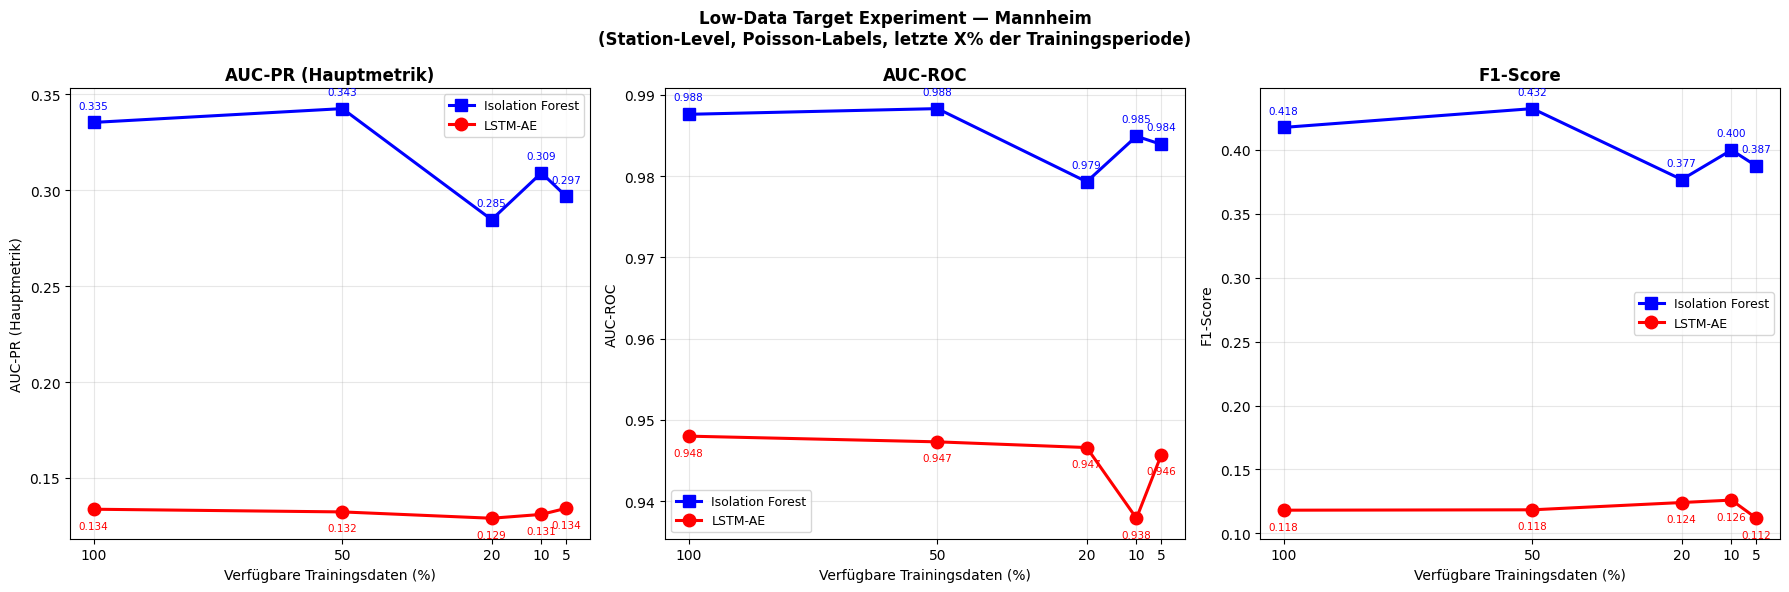


RELATIVE DEGRADATION (normiert auf 100%-Baseline)
    100% Daten  →  iForest: 100.0% der Baseline  |  LSTM-AE: 100.0% der Baseline
     50% Daten  →  iForest: 102.1% der Baseline  |  LSTM-AE:  99.0% der Baseline
     20% Daten  →  iForest:  84.9% der Baseline  |  LSTM-AE:  96.5% der Baseline
     10% Daten  →  iForest:  92.2% der Baseline  |  LSTM-AE:  98.0% der Baseline
      5% Daten  →  iForest:  88.5% der Baseline  |  LSTM-AE: 100.4% der Baseline

✅ Plot gespeichert: /content/data/experiment_plots/lowdata_degradation.png

→ Nächster Schritt: Phase 3/4 — Cross-City Transfer mit Source-Pretrain + Target-Finetune


In [26]:
# ══════════════════════════════════════════════════════════════
# 22c — Low-Data Visualisierung
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Low-Data Target Experiment — Mannheim\n'
             '(Station-Level, Poisson-Labels, letzte X% der Trainingsperiode)',
             fontsize=12, fontweight='bold')

metrics = [
    ('auc_pr',  'AUC-PR (Hauptmetrik)'),
    ('auc_roc', 'AUC-ROC'),
    ('f1',      'F1-Score'),
]

for ax, (metric, title) in zip(axes, metrics):
    ax.plot(ld_df['fraction'] * 100, ld_df[f'if_{metric}'],
            'bs-', lw=2.2, markersize=9, label='Isolation Forest', zorder=3)
    ax.plot(ld_df['fraction'] * 100, ld_df[f'ae_{metric}'],
            'ro-', lw=2.2, markersize=9, label='LSTM-AE', zorder=3)

    # Werte annotieren
    for _, row in ld_df.iterrows():
        pct = row['fraction'] * 100
        ax.annotate(f'{row[f"if_{metric}"]:.3f}',
                    (pct, row[f'if_{metric}']),
                    textcoords='offset points', xytext=(0, 10),
                    fontsize=7.5, ha='center', color='blue')
        ax.annotate(f'{row[f"ae_{metric}"]:.3f}',
                    (pct, row[f'ae_{metric}']),
                    textcoords='offset points', xytext=(0, -14),
                    fontsize=7.5, ha='center', color='red')

    ax.set_xlabel('Verfügbare Trainingsdaten (%)', fontsize=10)
    ax.set_ylabel(title, fontsize=10)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.invert_xaxis()
    ax.set_xticks([100, 50, 20, 10, 5])

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/lowdata_degradation.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Relative Degradation (normiert auf 100%-Wert) ──
print('\n' + '=' * 65)
print('RELATIVE DEGRADATION (normiert auf 100%-Baseline)')
print('=' * 65)
base_if = ld_df.loc[ld_df['fraction'] == 1.0, 'if_auc_pr'].values[0]
base_ae = ld_df.loc[ld_df['fraction'] == 1.0, 'ae_auc_pr'].values[0]

for _, row in ld_df.iterrows():
    pct   = row['fraction'] * 100
    if_rel = row['if_auc_pr'] / base_if * 100 if base_if > 0 else 0
    ae_rel = row['ae_auc_pr'] / base_ae * 100 if base_ae > 0 else 0
    print(f'  {pct:5.0f}% Daten  →  iForest: {if_rel:5.1f}% der Baseline  |  LSTM-AE: {ae_rel:5.1f}% der Baseline')

print(f'\n✅ Plot gespeichert: {PLOTS_DIR}/lowdata_degradation.png')
print('\n→ Nächster Schritt: Phase 3/4 — Cross-City Transfer mit Source-Pretrain + Target-Finetune')

NOCHMAL ANGEPASST


In [28]:
# ══════════════════════════════════════════════════════════════
# 22a — Low-Data Target Experiment: Setup (angepasst)
#
# Baut Station-Level + Poisson-Labels, fixiert Val/Test,
# bereitet AE-Sequenzen und iForest-Flat-Daten vor.
# ══════════════════════════════════════════════════════════════

import os
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_recall_curve, auc, f1_score, roc_auc_score
import matplotlib.pyplot as plt

print('=' * 65)
print('LOW-DATA TARGET EXPERIMENT — Setup')
print('=' * 65)

# Reproduzierbarkeit
RANDOM_SEED_LD = 42
np.random.seed(RANDOM_SEED_LD)
torch.manual_seed(RANDOM_SEED_LD)
rng_ld = np.random.default_rng(RANDOM_SEED_LD)

# Plot-Verzeichnis absichern
if 'PLOTS_DIR' not in globals():
    PLOTS_DIR = '/content/plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

# --- 1. Gewinner-Config aus Phase 2 übernehmen ---
cfg_ld = ExperimentConfig(
    run_id='lowdata_base',
    aggregation='station',       # Gewinner Set 1
    labeling='poisson',          # Gewinner Set 2
    model='lstm_ae',
    scoring='mse',
    feature_set='base'
)

# --- 2. Station-Level Daten + Poisson-Labels ---
df_ld = build_station_level(hourly_raw, cfg_ld)
feature_cols_ld = [c for c in get_feature_cols(cfg_ld) if c in df_ld.columns]
n_feat_ld = len(feature_cols_ld)

if len(feature_cols_ld) == 0:
    raise ValueError('Keine gültigen Feature-Spalten gefunden.')

# Temporale Grenzen (identisch zu Set 1–4)
t_min_ld  = df_ld['hour_ts'].min()
t_max_ld  = df_ld['hour_ts'].max()
total_h_ld = (t_max_ld - t_min_ld).total_seconds() / 3600
train_end_ld = t_min_ld + pd.Timedelta(hours=int(total_h_ld * TRAIN_RATIO))
val_end_ld   = t_min_ld + pd.Timedelta(hours=int(total_h_ld * VAL_RATIO))
train_duration_ld = train_end_ld - t_min_ld

# Labels (Stats aus voller Trainingsperiode → fixe Anomalie-Definition)
df_ld = compute_labels(df_ld, train_end_ld, cfg_ld, group_col='station_id')

# --- 3. Fixe Splits ---
df_train_full_ld = df_ld[
    (df_ld['hour_ts'] < train_end_ld) & (df_ld['label'] == 'normal')
].copy()

df_val_ld = df_ld[
    (df_ld['hour_ts'] >= train_end_ld) &
    (df_ld['hour_ts'] < val_end_ld) &
    (df_ld['label'] != 'grauzone')
].copy()

df_test_ld = df_ld[
    (df_ld['hour_ts'] >= val_end_ld) &
    (df_ld['label'] != 'grauzone')
].copy()

if len(df_train_full_ld) == 0 or len(df_val_ld) == 0 or len(df_test_ld) == 0:
    raise ValueError('Mindestens ein Split ist leer. Bitte Setup prüfen.')

# --- 4. Scaler auf VOLLER Trainingsperiode (fix für alle Fraktionen) ---
# Design-Entscheidung:
# Isoliert rein den Effekt der Datenmenge.
# In der Praxis würde man auch den Scaler nur mit verfügbaren Daten fitten.
scaler_ld = StandardScaler()
scaler_ld.fit(df_train_full_ld[feature_cols_ld].values)

# Demand-Indices für AE-Scoring (Reconstruction Error nur auf Demand-Features)
demand_idx_ld = [
    i for i, c in enumerate(feature_cols_ld)
    if c in ('total_demand', 'n_lends', 'n_returns',
             'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h')
]

# --- 5. Fixe Val/Test Sequenzen für AE (einmalig bauen) ---
W_ld = 24

def _build_station_sequences(df_split, scaler, feat_cols, window=24):
    """Sequenzen station-weise bauen, gibt (sequences, labels) zurück."""
    seqs_list, labels_list = [], []

    for sid in df_split['station_id'].unique():
        sub = df_split[df_split['station_id'] == sid].sort_values('hour_ts')
        scaled = scaler.transform(sub[feat_cols].values)
        labs = sub['label'].values
        n = len(scaled)

        if n < window:
            continue

        station_seqs = np.stack([scaled[i:i+window] for i in range(n - window + 1)])
        seqs_list.append(station_seqs)
        labels_list.append(labs[window-1:])

    if not seqs_list:
        return np.empty((0, window, len(feat_cols))), np.array([], dtype=object)

    return np.concatenate(seqs_list), np.concatenate(labels_list)

X_val_ld_full,  y_val_ld_full  = _build_station_sequences(df_val_ld,  scaler_ld, feature_cols_ld, W_ld)
X_test_ld_full, y_test_ld_full = _build_station_sequences(df_test_ld, scaler_ld, feature_cols_ld, W_ld)

if len(X_val_ld_full) == 0 or len(X_test_ld_full) == 0:
    raise ValueError('Val/Test-Sequenzen konnten nicht gebaut werden.')

# Val für AE subsampling (stratifiziert, konsistent mit run_experiment)
MAX_VAL_AE = 15_000
if len(X_val_ld_full) > MAX_VAL_AE:
    _anom_idx = np.where(y_val_ld_full == 'anomal')[0]
    _norm_idx = np.where(y_val_ld_full != 'anomal')[0]
    _n_norm = min(MAX_VAL_AE - len(_anom_idx), len(_norm_idx))

    _chosen = np.sort(np.concatenate([
        _anom_idx,
        rng_ld.choice(_norm_idx, _n_norm, replace=False)
    ]))

    X_val_ae_ld = X_val_ld_full[_chosen]
    y_val_ae_ld = y_val_ld_full[_chosen]
else:
    X_val_ae_ld = X_val_ld_full
    y_val_ae_ld = y_val_ld_full

# Fixe Flat-Daten für iForest
val_flat_ld  = scaler_ld.transform(df_val_ld[feature_cols_ld].values)
test_flat_ld = scaler_ld.transform(df_test_ld[feature_cols_ld].values)
y_val_if_ld  = df_val_ld['label'].values
y_test_if_ld = df_test_ld['label'].values

# --- Summary ---
FRACTIONS_LD = [1.0, 0.5, 0.2, 0.1, 0.05, 0.01]

print(f'\nTrainperiode: {t_min_ld.date()} – {train_end_ld.date()}')
print(f'Val:  {len(df_val_ld):>10,} Zeilen | {len(X_val_ld_full):>8,} AE-Seqs | anomal: {(y_val_ld_full=="anomal").sum():,}')
print(f'Test: {len(df_test_ld):>10,} Zeilen | {len(X_test_ld_full):>8,} AE-Seqs | anomal: {(y_test_ld_full=="anomal").sum():,}')
print(f'Full Training (normal): {len(df_train_full_ld):,} Zeilen')

print(f'\nGeplante Fraktionen:')
for frac in FRACTIONS_LD:
    cutoff = train_end_ld - pd.Timedelta(seconds=train_duration_ld.total_seconds() * frac)
    n_rows = len(df_train_full_ld[df_train_full_ld['hour_ts'] >= cutoff])
    n_days = (train_end_ld - cutoff).days
    print(f'  {frac:5.0%}  →  letzte ~{n_days:>3d} Tage  (ab {cutoff.date()})  →  ~{n_rows:>9,} Train-Zeilen')

print('\n✅ Setup abgeschlossen. Val/Test sind fixiert.')

LOW-DATA TARGET EXPERIMENT — Setup

Trainperiode: 2023-04-07 – 2025-02-27
Val:     325,082 Zeilen |  323,058 AE-Seqs | anomal: 3,746
Test:    352,534 Zeilen |  350,510 AE-Seqs | anomal: 3,151
Full Training (normal): 1,380,904 Zeilen

Geplante Fraktionen:
   100%  →  letzte ~691 Tage  (ab 2023-04-07)  →  ~1,380,904 Train-Zeilen
    50%  →  letzte ~345 Tage  (ab 2024-03-18)  →  ~  688,952 Train-Zeilen
    20%  →  letzte ~138 Tage  (ab 2024-10-12)  →  ~  277,833 Train-Zeilen
    10%  →  letzte ~ 69 Tage  (ab 2024-12-20)  →  ~  141,233 Train-Zeilen
     5%  →  letzte ~ 34 Tage  (ab 2025-01-23)  →  ~   69,783 Train-Zeilen
     1%  →  letzte ~  6 Tage  (ab 2025-02-20)  →  ~   13,442 Train-Zeilen

✅ Setup abgeschlossen. Val/Test sind fixiert.


In [29]:
# ══════════════════════════════════════════════════════════════
# 22b — Low-Data Runs: iForest + LSTM-AE je Fraktion (angepasst)
# ══════════════════════════════════════════════════════════════

def run_lowdata_fraction(frac, rng=None):
    """Führt iForest + LSTM-AE für eine Train-Fraktion aus."""
    if rng is None:
        rng = np.random.default_rng(42)

    # --- Zeitkonsistentes Train-Subset: letzte X% ---
    cutoff = train_end_ld - pd.Timedelta(seconds=train_duration_ld.total_seconds() * frac)
    df_frac = df_train_full_ld[df_train_full_ld['hour_ts'] >= cutoff].copy()

    n_stations = df_frac['station_id'].nunique()
    n_days_frac = (train_end_ld - cutoff).days

    print(f'\n{"="*65}')
    print(f'FRAKTION {frac:.0%} | letzte ~{n_days_frac} Tage | {len(df_frac):,} Zeilen | {n_stations} Stationen')
    print(f'{"="*65}')

    res = {
        'fraction': frac,
        'n_train_days': n_days_frac,
        'cutoff_date': str(cutoff.date()),
        'n_train_rows': int(len(df_frac)),
        'n_stations': int(n_stations)
    }

    # Sicherheitscheck
    if len(df_frac) == 0:
        print('  ⚠️ Leeres Train-Subset.')
        res.update({
            'if_auc_pr': 0, 'if_f1': 0, 'if_auc_roc': 0,
            'ae_auc_pr': 0, 'ae_f1': 0, 'ae_auc_roc': 0,
            'ae_n_train_seqs': 0
        })
        return res

    # ═══ iForest ═══
    print('  ── Isolation Forest ──')
    train_flat = scaler_ld.transform(df_frac[feature_cols_ld].values)

    clf = IsolationForest(
        n_estimators=200,
        contamination=0.005,
        random_state=42,
        n_jobs=-1
    )
    clf.fit(train_flat)

    sc_val_if  = -clf.decision_function(val_flat_ld)
    sc_test_if = -clf.decision_function(test_flat_ld)

    thr_if, _ = find_best_threshold(sc_val_if, y_val_if_ld)
    bin_test_if = (y_test_if_ld == 'anomal').astype(int)
    pred_if = (sc_test_if > thr_if).astype(int)

    prec_if, rec_if, _ = precision_recall_curve(bin_test_if, sc_test_if)
    res['if_auc_pr'] = round(auc(rec_if, prec_if), 4)
    res['if_f1'] = round(f1_score(bin_test_if, pred_if, zero_division=0), 4)
    try:
        res['if_auc_roc'] = round(roc_auc_score(bin_test_if, sc_test_if), 4)
    except:
        res['if_auc_roc'] = 0.0

    print(f'     AUC-PR: {res["if_auc_pr"]:.4f} | F1: {res["if_f1"]:.4f} | AUC-ROC: {res["if_auc_roc"]:.4f}')

    # ═══ LSTM-AE ═══
    print('  ── LSTM-AE ──')
    MAX_TRAIN_SEQS = 50_000
    train_seqs = []

    for sid in df_frac['station_id'].unique():
        sub = df_frac[df_frac['station_id'] == sid].sort_values('hour_ts')
        scaled = scaler_ld.transform(sub[feature_cols_ld].values)
        n = len(scaled)

        if n < W_ld:
            continue

        seqs = np.stack([scaled[i:i+W_ld] for i in range(n - W_ld + 1)])
        train_seqs.append(seqs)

    if not train_seqs:
        print('     ⚠️ Keine Train-Sequenzen → AE übersprungen.')
        res.update({
            'ae_auc_pr': 0,
            'ae_f1': 0,
            'ae_auc_roc': 0,
            'ae_n_train_seqs': 0
        })
        return res

    X_train_ae = np.concatenate(train_seqs)

    if len(X_train_ae) > MAX_TRAIN_SEQS:
        idx = rng.choice(len(X_train_ae), MAX_TRAIN_SEQS, replace=False)
        idx = np.sort(idx)
        X_train_ae = X_train_ae[idx]

    res['ae_n_train_seqs'] = int(len(X_train_ae))
    print(f'     Train-Seqs: {len(X_train_ae):,}')

    model = LSTMAutoencoder(n_features=n_feat_ld, latent_dim=LATENT_DIM)
    model = train_ae(
        model,
        X_train_ae,
        X_val_ae_ld,
        model_name=f'AE_{int(frac*100)}pct',
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        lr=LEARNING_RATE,
        patience=EARLY_STOP
    )

    sc_val_ae = compute_ae_scores(
        model,
        X_val_ae_ld,
        scoring='mse',
        demand_indices=demand_idx_ld,
        window_size=W_ld,
        n_features=n_feat_ld
    )
    sc_test_ae = compute_ae_scores(
        model,
        X_test_ld_full,
        scoring='mse',
        demand_indices=demand_idx_ld,
        window_size=W_ld,
        n_features=n_feat_ld
    )

    thr_ae, _ = find_best_threshold(sc_val_ae, y_val_ae_ld)
    bin_test_ae = (y_test_ld_full == 'anomal').astype(int)
    pred_ae = (sc_test_ae > thr_ae).astype(int)

    prec_ae, rec_ae, _ = precision_recall_curve(bin_test_ae, sc_test_ae)
    res['ae_auc_pr'] = round(auc(rec_ae, prec_ae), 4)
    res['ae_f1'] = round(f1_score(bin_test_ae, pred_ae, zero_division=0), 4)
    try:
        res['ae_auc_roc'] = round(roc_auc_score(bin_test_ae, sc_test_ae), 4)
    except:
        res['ae_auc_roc'] = 0.0

    print(f'     AUC-PR: {res["ae_auc_pr"]:.4f} | F1: {res["ae_f1"]:.4f} | AUC-ROC: {res["ae_auc_roc"]:.4f}')

    model.cpu()
    torch.cuda.empty_cache()
    del X_train_ae

    return res


# ── Alle Fraktionen ausführen ──
lowdata_results = []
for frac in FRACTIONS_LD:
    lowdata_results.append(run_lowdata_fraction(frac, rng=rng_ld))

ld_df = pd.DataFrame(lowdata_results)

print('\n' + '=' * 80)
print('LOW-DATA ERGEBNISSE — Degradation bei reduzierter Trainingsmenge')
print('=' * 80)
display(ld_df[[
    'fraction', 'n_train_days', 'n_train_rows',
    'if_auc_pr', 'if_f1', 'if_auc_roc',
    'ae_auc_pr', 'ae_f1', 'ae_auc_roc',
    'ae_n_train_seqs'
]])

ld_df.to_csv('/content/data/lowdata_results.csv', index=False)
print('\n✅ Ergebnisse gespeichert: /content/data/lowdata_results.csv')


FRAKTION 100% | letzte ~691 Tage | 1,380,904 Zeilen | 88 Stationen
  ── Isolation Forest ──
     AUC-PR: 0.3396 | F1: 0.4057 | AUC-ROC: 0.9870
  ── LSTM-AE ──
     Train-Seqs: 50,000
  [AE_100pct] Epoch  10 | Train: 0.39334 | Val: 1.04202
  [AE_100pct] Epoch  20 | Train: 0.29270 | Val: 0.84837
  [AE_100pct] Epoch  30 | Train: 0.26219 | Val: 0.77207
  [AE_100pct] Epoch  40 | Train: 0.24772 | Val: 0.73134
  [AE_100pct] Epoch  50 | Train: 0.23730 | Val: 0.70938
  [AE_100pct] Best Val Loss: 0.708923
     AUC-PR: 0.1349 | F1: 0.1142 | AUC-ROC: 0.9479

FRAKTION 50% | letzte ~345 Tage | 688,952 Zeilen | 88 Stationen
  ── Isolation Forest ──
     AUC-PR: 0.3330 | F1: 0.4076 | AUC-ROC: 0.9864
  ── LSTM-AE ──
     Train-Seqs: 50,000
  [AE_50pct] Epoch  10 | Train: 0.40435 | Val: 1.04356
  [AE_50pct] Epoch  20 | Train: 0.31253 | Val: 0.86228
  [AE_50pct] Epoch  30 | Train: 0.28256 | Val: 0.79605
  [AE_50pct] Epoch  40 | Train: 0.26575 | Val: 0.75635
  [AE_50pct] Epoch  50 | Train: 0.25253 | Val:

,fraction,n_train_days,n_train_rows,if_auc_pr,if_f1,if_auc_roc,ae_auc_pr,ae_f1,ae_auc_roc,ae_n_train_seqs
0,1.00,691,1380904,0.3396,0.4057,0.9870,0.1349,0.1142,0.9479,50000
1,0.50,345,688952,0.3330,0.4076,0.9864,0.1336,0.1167,0.9479,50000
2,0.20,138,277833,0.3204,0.4059,0.9837,0.1354,0.1361,0.9476,50000
3,0.10,69,141233,0.3171,0.4028,0.9852,0.1328,0.1256,0.9393,50000
4,0.05,34,69783,0.3149,0.3992,0.9858,0.1404,0.1119,0.9477,50000
5,0.01,6,13442,0.3642,0.4356,0.9887,0.1337,0.1230,0.9457,11418



✅ Ergebnisse gespeichert: /content/data/lowdata_results.csv


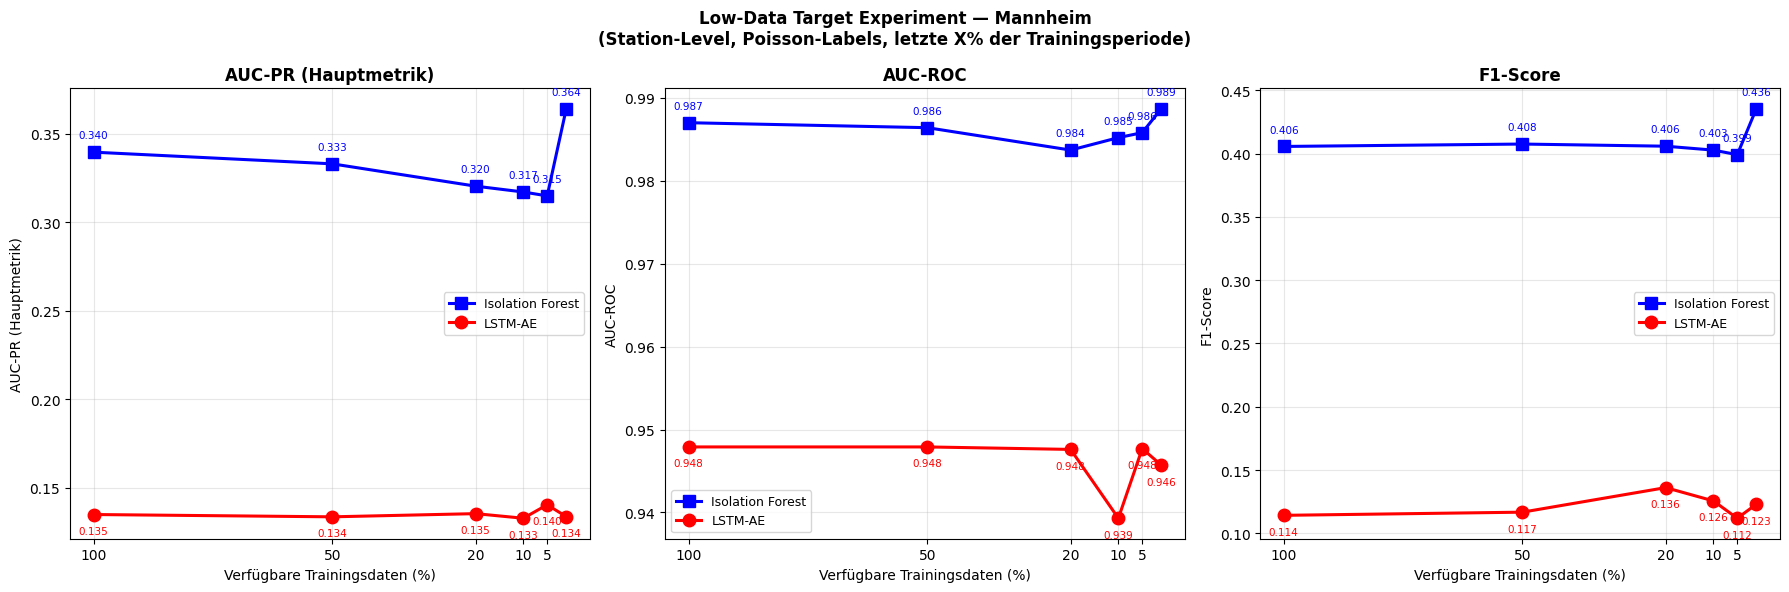


RELATIVE DEGRADATION (normiert auf 100%-Baseline)
    100% Daten  →  iForest: 100.0% der Baseline  |  LSTM-AE: 100.0% der Baseline
     50% Daten  →  iForest:  98.1% der Baseline  |  LSTM-AE:  99.0% der Baseline
     20% Daten  →  iForest:  94.3% der Baseline  |  LSTM-AE: 100.4% der Baseline
     10% Daten  →  iForest:  93.4% der Baseline  |  LSTM-AE:  98.4% der Baseline
      5% Daten  →  iForest:  92.7% der Baseline  |  LSTM-AE: 104.1% der Baseline
      1% Daten  →  iForest: 107.2% der Baseline  |  LSTM-AE:  99.1% der Baseline

✅ Plot gespeichert: /content/data/experiment_plots/lowdata_degradation.png

→ Nächster Schritt: Phase 3/4 — Cross-City Transfer mit Source-Pretrain + Target-Finetune


In [30]:
# ══════════════════════════════════════════════════════════════
# 22c — Low-Data Visualisierung
# ══════════════════════════════════════════════════════════════

if 'ld_df' not in globals() or len(ld_df) == 0:
    raise ValueError('ld_df ist leer oder nicht vorhanden.')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    'Low-Data Target Experiment — Mannheim\n'
    '(Station-Level, Poisson-Labels, letzte X% der Trainingsperiode)',
    fontsize=12,
    fontweight='bold'
)

metrics = [
    ('auc_pr',  'AUC-PR (Hauptmetrik)'),
    ('auc_roc', 'AUC-ROC'),
    ('f1',      'F1-Score'),
]

for ax, (metric, title) in zip(axes, metrics):
    ax.plot(
        ld_df['fraction'] * 100,
        ld_df[f'if_{metric}'],
        'bs-',
        lw=2.2,
        markersize=9,
        label='Isolation Forest',
        zorder=3
    )
    ax.plot(
        ld_df['fraction'] * 100,
        ld_df[f'ae_{metric}'],
        'ro-',
        lw=2.2,
        markersize=9,
        label='LSTM-AE',
        zorder=3
    )

    for _, row in ld_df.iterrows():
        pct = row['fraction'] * 100
        ax.annotate(
            f'{row[f"if_{metric}"]:.3f}',
            (pct, row[f'if_{metric}']),
            textcoords='offset points',
            xytext=(0, 10),
            fontsize=7.5,
            ha='center',
            color='blue'
        )
        ax.annotate(
            f'{row[f"ae_{metric}"]:.3f}',
            (pct, row[f'ae_{metric}']),
            textcoords='offset points',
            xytext=(0, -14),
            fontsize=7.5,
            ha='center',
            color='red'
        )

    ax.set_xlabel('Verfügbare Trainingsdaten (%)', fontsize=10)
    ax.set_ylabel(title, fontsize=10)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.invert_xaxis()
    ax.set_xticks([100, 50, 20, 10, 5])

plt.tight_layout()
plot_path = f'{PLOTS_DIR}/lowdata_degradation.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '=' * 65)
print('RELATIVE DEGRADATION (normiert auf 100%-Baseline)')
print('=' * 65)

base_if = ld_df.loc[ld_df['fraction'] == 1.0, 'if_auc_pr'].values[0]
base_ae = ld_df.loc[ld_df['fraction'] == 1.0, 'ae_auc_pr'].values[0]

for _, row in ld_df.iterrows():
    pct = row['fraction'] * 100
    if_rel = row['if_auc_pr'] / base_if * 100 if base_if > 0 else 0
    ae_rel = row['ae_auc_pr'] / base_ae * 100 if base_ae > 0 else 0
    print(f'  {pct:5.0f}% Daten  →  iForest: {if_rel:5.1f}% der Baseline  |  LSTM-AE: {ae_rel:5.1f}% der Baseline')

print(f'\n✅ Plot gespeichert: {plot_path}')
print('\n→ Nächster Schritt: Phase 3/4 — Cross-City Transfer mit Source-Pretrain + Target-Finetune')

JETZT MIT WIRKLICH FAIREM VERGLEICH DURCH KEIN BACKGROUND KNOWLEDGE

In [31]:
# ══════════════════════════════════════════════════════════════
# 22a — Low-Data Cold-Start: Setup
#
# Ground-Truth-Labels einmalig berechnen (volle Trainingsperiode),
# Val/Test fixieren. Alles andere wird pro Fraktion neu gebaut.
# ══════════════════════════════════════════════════════════════

print('=' * 65)
print('LOW-DATA COLD-START EXPERIMENT — Setup')
print('=' * 65)

# Reproduzierbarkeit
RANDOM_SEED_LD = 42
np.random.seed(RANDOM_SEED_LD)
torch.manual_seed(RANDOM_SEED_LD)
rng_ld = np.random.default_rng(RANDOM_SEED_LD)

# --- 1. Gewinner-Config ---
cfg_ld = ExperimentConfig(
    run_id='lowdata_coldstart',
    aggregation='station',
    labeling='poisson',
    model='lstm_ae',
    scoring='mse',
    feature_set='base'
)

# --- 2. Station-Level Daten aufbauen ---
df_ld = build_station_level(hourly_raw, cfg_ld)
feature_cols_ld = [c for c in get_feature_cols(cfg_ld) if c in df_ld.columns]
n_feat_ld = len(feature_cols_ld)

# Demand-Indices fuer AE-Scoring
demand_idx_ld = [
    i for i, c in enumerate(feature_cols_ld)
    if c in ("total_demand", "n_lends", "n_returns",
             "demand_lag_1h", "demand_lag_24h", "demand_lag_168h")
]

# Temporale Grenzen
t_min_ld  = df_ld['hour_ts'].min()
t_max_ld  = df_ld['hour_ts'].max()
total_h_ld = (t_max_ld - t_min_ld).total_seconds() / 3600
train_end_ld = t_min_ld + pd.Timedelta(hours=int(total_h_ld * TRAIN_RATIO))
val_end_ld   = t_min_ld + pd.Timedelta(hours=int(total_h_ld * VAL_RATIO))
train_duration_ld = train_end_ld - t_min_ld

# --- 3. Ground-Truth-Labels (volle Trainingsperiode = Orakel) ---
# Diese werden NUR fuer Val/Test-Evaluation verwendet, NICHT fuers Training.
df_ld = compute_labels(df_ld, train_end_ld, cfg_ld, group_col='station_id')
gt_anomaly_rate = (df_ld['label'] == 'anomal').mean()

# --- 4. Fixe Splits (Zeitraeume + Ground-Truth Labels) ---
df_train_pool_ld = df_ld[df_ld['hour_ts'] < train_end_ld].copy()

df_val_ld = df_ld[
    (df_ld['hour_ts'] >= train_end_ld) &
    (df_ld['hour_ts'] < val_end_ld) &
    (df_ld['label'] != 'grauzone')
].copy()

df_test_ld = df_ld[
    (df_ld['hour_ts'] >= val_end_ld) &
    (df_ld['label'] != 'grauzone')
].copy()

# --- 5. Konfiguration ---
W_ld = 24
MAX_TRAIN_SEQS_LD = 50_000
MAX_VAL_AE_LD = 15_000
FRACTIONS_LD = [1.0, 0.5, 0.2, 0.1, 0.05, 0.01]

# --- Summary ---
print(f'\nTrainperiode: {t_min_ld.date()} - {train_end_ld.date()} ({train_duration_ld.days} Tage)')
print(f'Ground-Truth Anomalie-Rate: {gt_anomaly_rate:.4f}')
print(f'Val:  {len(df_val_ld):>10,} Zeilen | anomal: {(df_val_ld["label"]=="anomal").sum():,}')
print(f'Test: {len(df_test_ld):>10,} Zeilen | anomal: {(df_test_ld["label"]=="anomal").sum():,}')
print(f'Train-Pool (alle Labels): {len(df_train_pool_ld):,} Zeilen')

print(f'\nGeplante Fraktionen:')
for frac in FRACTIONS_LD:
    cutoff = train_end_ld - pd.Timedelta(seconds=train_duration_ld.total_seconds() * frac)
    n_rows = len(df_train_pool_ld[df_train_pool_ld['hour_ts'] >= cutoff])
    n_days = (train_end_ld - cutoff).days
    print(f'  {frac:5.0%}  ->  letzte ~{n_days:>3d} Tage  ->  ~{n_rows:>9,} Zeilen (ALLE, kein Label-Filter)')

print('\n✅ Setup abgeschlossen.')
print('   Val/Test: Ground-Truth Labels fixiert')
print('   Training: Pro Fraktion ALLES neu (Scaler, Daten, kein Vorwissen)')

LOW-DATA COLD-START EXPERIMENT — Setup

Trainperiode: 2023-04-07 - 2025-02-27 (691 Tage)
Ground-Truth Anomalie-Rate: 0.0085
Val:     325,082 Zeilen | anomal: 3,757
Test:    352,534 Zeilen | anomal: 3,163
Train-Pool (alle Labels): 1,460,272 Zeilen

Geplante Fraktionen:
   100%  ->  letzte ~691 Tage  ->  ~1,460,272 Zeilen (ALLE, kein Label-Filter)
    50%  ->  letzte ~345 Tage  ->  ~  730,136 Zeilen (ALLE, kein Label-Filter)
    20%  ->  letzte ~138 Tage  ->  ~  291,984 Zeilen (ALLE, kein Label-Filter)
    10%  ->  letzte ~ 69 Tage  ->  ~  145,992 Zeilen (ALLE, kein Label-Filter)
     5%  ->  letzte ~ 34 Tage  ->  ~   72,952 Zeilen (ALLE, kein Label-Filter)
     1%  ->  letzte ~  6 Tage  ->  ~   14,520 Zeilen (ALLE, kein Label-Filter)

✅ Setup abgeschlossen.
   Val/Test: Ground-Truth Labels fixiert
   Training: Pro Fraktion ALLES neu (Scaler, Daten, kein Vorwissen)


In [32]:
# ══════════════════════════════════════════════════════════════
# 22b — Low-Data Cold-Start Runs
#
# Pro Fraktion: Scaler neu, Training auf ALLEN Daten (kein
# Label-Filter), Val/Test neu skaliert, Evaluation gegen
# fixe Ground-Truth-Labels.
# ══════════════════════════════════════════════════════════════

def _build_seqs_stationwise(df, scaler, feat_cols, window=24):
    # Station-weise Sequenzen bauen. Gibt (seqs, label_arrays) zurueck.
    seqs_list, labels_list = [], []
    for sid in df['station_id'].unique():
        sub = df[df['station_id'] == sid].sort_values('hour_ts')
        scaled = scaler.transform(sub[feat_cols].values)
        labs = sub['label'].values
        n = len(scaled)
        if n < window:
            continue
        seqs = np.stack([scaled[i:i+window] for i in range(n - window + 1)])
        seqs_list.append(seqs)
        labels_list.append(labs[window-1:])
    if not seqs_list:
        return np.empty((0, window, len(feat_cols))), np.array([], dtype=object)
    return np.concatenate(seqs_list), np.concatenate(labels_list)


def run_lowdata_coldstart(frac, rng):
    # Realistischer Cold-Start Run fuer eine Fraktion.

    # --- 1. Zeitkonsistentes Train-Subset (letzte X%, ALLE Daten) ---
    cutoff = train_end_ld - pd.Timedelta(
        seconds=train_duration_ld.total_seconds() * frac
    )
    df_frac = df_train_pool_ld[df_train_pool_ld['hour_ts'] >= cutoff].copy()
    n_stations = df_frac['station_id'].nunique()
    n_days_frac = (train_end_ld - cutoff).days

    print(f'\n{"="*65}')
    print(f'FRAKTION {frac:.0%} | ~{n_days_frac} Tage | {len(df_frac):,} Zeilen | '
          f'{n_stations} Stationen | KEIN Vorwissen')
    print(f'{"="*65}')

    # Label-Verteilung in der Fraktion (nur zur Info, wird NICHT zum Filtern genutzt)
    frac_labels = df_frac['label'].value_counts().to_dict()
    print(f'  Info - Labels in Fraktion (nicht genutzt): {frac_labels}')

    res = {
        'fraction': frac,
        'n_train_days': n_days_frac,
        'cutoff_date': str(cutoff.date()),
        'n_train_rows': int(len(df_frac)),
        'n_stations': int(n_stations),
    }

    if len(df_frac) < 100:
        print('  ⚠️  Zu wenig Daten. Uebersprungen.')
        res.update({k: 0.0 for k in [
            'if_auc_pr','if_f1','if_auc_roc',
            'ae_auc_pr','ae_f1','ae_auc_roc','ae_n_train_seqs'
        ]})
        return res

    # --- 2. Scaler NUR auf Fraktions-Daten fitten ---
    scaler_frac = StandardScaler()
    scaler_frac.fit(df_frac[feature_cols_ld].values)

    # --- 3. Val/Test mit Fraktions-Scaler skalieren ---
    val_flat  = scaler_frac.transform(df_val_ld[feature_cols_ld].values)
    test_flat = scaler_frac.transform(df_test_ld[feature_cols_ld].values)
    y_val_gt  = df_val_ld['label'].values    # Ground Truth
    y_test_gt = df_test_ld['label'].values   # Ground Truth

    # =========== iForest ===========
    print('  -- Isolation Forest --')
    train_flat = scaler_frac.transform(df_frac[feature_cols_ld].values)

    clf = IsolationForest(
        n_estimators=200,
        contamination=0.005,
        random_state=42,
        n_jobs=-1
    )
    clf.fit(train_flat)  # Auf ALLEN Fraktions-Daten (inkl. etwaige Anomalien)

    sc_val_if  = -clf.decision_function(val_flat)
    sc_test_if = -clf.decision_function(test_flat)

    thr_if, _ = find_best_threshold(sc_val_if, y_val_gt)
    bin_test_if = (y_test_gt == 'anomal').astype(int)
    pred_if = (sc_test_if > thr_if).astype(int)

    prec_if, rec_if, _ = precision_recall_curve(bin_test_if, sc_test_if)
    res['if_auc_pr']  = round(auc(rec_if, prec_if), 4)
    res['if_f1']      = round(f1_score(bin_test_if, pred_if, zero_division=0), 4)
    try:
        res['if_auc_roc'] = round(roc_auc_score(bin_test_if, sc_test_if), 4)
    except:
        res['if_auc_roc'] = 0.0

    print(f'     AUC-PR: {res["if_auc_pr"]:.4f} | F1: {res["if_f1"]:.4f} | '
          f'AUC-ROC: {res["if_auc_roc"]:.4f}')

    # =========== LSTM-AE ===========
    print('  -- LSTM-AE --')

    # Train-Sequenzen (ALLE Daten, kein Label-Filter)
    train_seqs = []
    for sid in df_frac['station_id'].unique():
        sub = df_frac[df_frac['station_id'] == sid].sort_values('hour_ts')
        scaled = scaler_frac.transform(sub[feature_cols_ld].values)
        n = len(scaled)
        if n < W_ld:
            continue
        seqs = np.stack([scaled[i:i+W_ld] for i in range(n - W_ld + 1)])
        train_seqs.append(seqs)

    if not train_seqs:
        print('     ⚠️ Keine Train-Sequenzen -> AE uebersprungen.')
        res.update({'ae_auc_pr': 0, 'ae_f1': 0, 'ae_auc_roc': 0,
                    'ae_n_train_seqs': 0})
        return res

    X_train_ae = np.concatenate(train_seqs)
    if len(X_train_ae) > MAX_TRAIN_SEQS_LD:
        idx = rng.choice(len(X_train_ae), MAX_TRAIN_SEQS_LD, replace=False)
        X_train_ae = X_train_ae[np.sort(idx)]

    res['ae_n_train_seqs'] = int(len(X_train_ae))
    print(f'     Train-Seqs: {len(X_train_ae):,} (ungefiltert, inkl. Anomalien)')

    # Val-Sequenzen mit Fraktions-Scaler
    X_val_ae, y_val_ae = _build_seqs_stationwise(
        df_val_ld, scaler_frac, feature_cols_ld, W_ld
    )

    # Val subsampling
    if len(X_val_ae) > MAX_VAL_AE_LD:
        a_idx = np.where(y_val_ae == 'anomal')[0]
        n_idx = np.where(y_val_ae != 'anomal')[0]
        n_keep = min(MAX_VAL_AE_LD - len(a_idx), len(n_idx))
        chosen = np.sort(np.concatenate([
            a_idx, rng.choice(n_idx, n_keep, replace=False)
        ]))
        X_val_ae = X_val_ae[chosen]
        y_val_ae = y_val_ae[chosen]

    # Test-Sequenzen mit Fraktions-Scaler
    X_test_ae, y_test_ae = _build_seqs_stationwise(
        df_test_ld, scaler_frac, feature_cols_ld, W_ld
    )

    if len(X_val_ae) == 0 or len(X_test_ae) == 0:
        print('     ⚠️ Val/Test-Sequenzen leer -> AE uebersprungen.')
        res.update({'ae_auc_pr': 0, 'ae_f1': 0, 'ae_auc_roc': 0})
        return res

    # Modell trainieren
    model = LSTMAutoencoder(n_features=n_feat_ld, latent_dim=LATENT_DIM)
    model = train_ae(
        model, X_train_ae, X_val_ae,
        model_name=f'AE_{int(frac*100)}pct',
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        lr=LEARNING_RATE, patience=EARLY_STOP
    )

    # Scoring
    sc_val_ae = compute_ae_scores(
        model, X_val_ae, scoring='mse',
        demand_indices=demand_idx_ld,
        window_size=W_ld, n_features=n_feat_ld
    )
    sc_test_ae = compute_ae_scores(
        model, X_test_ae, scoring='mse',
        demand_indices=demand_idx_ld,
        window_size=W_ld, n_features=n_feat_ld
    )

    # Evaluation gegen Ground Truth
    thr_ae, _ = find_best_threshold(sc_val_ae, y_val_ae)
    bin_test_ae = (y_test_ae == 'anomal').astype(int)
    pred_ae = (sc_test_ae > thr_ae).astype(int)

    prec_ae, rec_ae, _ = precision_recall_curve(bin_test_ae, sc_test_ae)
    res['ae_auc_pr']  = round(auc(rec_ae, prec_ae), 4)
    res['ae_f1']      = round(f1_score(bin_test_ae, pred_ae, zero_division=0), 4)
    try:
        res['ae_auc_roc'] = round(roc_auc_score(bin_test_ae, sc_test_ae), 4)
    except:
        res['ae_auc_roc'] = 0.0

    print(f'     AUC-PR: {res["ae_auc_pr"]:.4f} | F1: {res["ae_f1"]:.4f} | '
          f'AUC-ROC: {res["ae_auc_roc"]:.4f}')

    model.cpu()
    torch.cuda.empty_cache()

    return res


# -- Alle Fraktionen ausfuehren --
lowdata_results = []
for frac in FRACTIONS_LD:
    lowdata_results.append(run_lowdata_coldstart(frac, rng=rng_ld))

ld_df = pd.DataFrame(lowdata_results)

print('\n' + '=' * 80)
print('LOW-DATA COLD-START ERGEBNISSE')
print('=' * 80)
display(ld_df[[
    'fraction', 'n_train_days', 'n_train_rows', 'n_stations',
    'if_auc_pr', 'if_f1', 'if_auc_roc',
    'ae_auc_pr', 'ae_f1', 'ae_auc_roc', 'ae_n_train_seqs'
]])

ld_df.to_csv('/content/data/lowdata_coldstart_results.csv', index=False)
print(f'\n✅ Ergebnisse gespeichert: /content/data/lowdata_coldstart_results.csv')


FRAKTION 100% | ~691 Tage | 1,460,272 Zeilen | 88 Stationen | KEIN Vorwissen
  Info - Labels in Fraktion (nicht genutzt): {'normal': 1380904, 'grauzone': 67693, 'anomal': 11675}
  -- Isolation Forest --
     AUC-PR: 0.3548 | F1: 0.4095 | AUC-ROC: 0.9856
  -- LSTM-AE --
     Train-Seqs: 50,000 (ungefiltert, inkl. Anomalien)
  [AE_100pct] Epoch  10 | Train: 0.36894 | Val: 0.66317
  [AE_100pct] Epoch  20 | Train: 0.28083 | Val: 0.55892
  [AE_100pct] Epoch  30 | Train: 0.24901 | Val: 0.51835
  [AE_100pct] Epoch  40 | Train: 0.23352 | Val: 0.50401
  [AE_100pct] Epoch  50 | Train: 0.22251 | Val: 0.48544
  [AE_100pct] Best Val Loss: 0.485436
     AUC-PR: 0.1173 | F1: 0.1143 | AUC-ROC: 0.9425

FRAKTION 50% | ~345 Tage | 730,136 Zeilen | 88 Stationen | KEIN Vorwissen
  Info - Labels in Fraktion (nicht genutzt): {'normal': 688952, 'grauzone': 35204, 'anomal': 5980}
  -- Isolation Forest --
     AUC-PR: 0.3375 | F1: 0.4019 | AUC-ROC: 0.9836
  -- LSTM-AE --
     Train-Seqs: 50,000 (ungefiltert, i

,fraction,n_train_days,n_train_rows,n_stations,if_auc_pr,if_f1,if_auc_roc,ae_auc_pr,ae_f1,ae_auc_roc,ae_n_train_seqs
0,1.00,691,1460272,88,0.3548,0.4095,0.9856,0.1173,0.1143,0.9425,50000
1,0.50,345,730136,88,0.3375,0.4019,0.9836,0.1129,0.1107,0.9425,50000
2,0.20,138,291984,88,0.3118,0.3934,0.9735,0.1174,0.1306,0.9370,50000
3,0.10,69,145992,88,0.3320,0.4041,0.9840,0.1161,0.1016,0.9319,50000
4,0.05,34,72952,88,0.3233,0.3845,0.9822,0.1315,0.1056,0.9397,50000
5,0.01,6,14520,88,0.3555,0.4007,0.9830,0.1084,0.0968,0.9236,12496



✅ Ergebnisse gespeichert: /content/data/lowdata_coldstart_results.csv


In [ ]:
# ══════════════════════════════════════════════════════════════
# 22c — Low-Data Cold-Start Visualisierung
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Low-Data Cold-Start Experiment — Mannheim (Realistisch)\n'
             'Scaler + Training pro Fraktion NEU, Val/Test Ground-Truth fix',
             fontsize=12, fontweight='bold')

metrics = [
    ('auc_pr',  'AUC-PR (Hauptmetrik)'),
    ('auc_roc', 'AUC-ROC'),
    ('f1',      'F1-Score'),
]

x_vals = ld_df['fraction'] * 100

for ax, (metric, title) in zip(axes, metrics):
    ax.plot(x_vals, ld_df[f'if_{metric}'],
            'bs-', lw=2.2, markersize=9, label='Isolation Forest', zorder=3)
    ax.plot(x_vals, ld_df[f'ae_{metric}'],
            'ro-', lw=2.2, markersize=9, label='LSTM-AE', zorder=3)

    for _, row in ld_df.iterrows():
        pct = row['fraction'] * 100
        ax.annotate(f'{row[f"if_{metric}"]:.3f}',
                    (pct, row[f'if_{metric}']),
                    textcoords='offset points', xytext=(0, 10),
                    fontsize=7.5, ha='center', color='blue')
        ax.annotate(f'{row[f"ae_{metric}"]:.3f}',
                    (pct, row[f'ae_{metric}']),
                    textcoords='offset points', xytext=(0, -14),
                    fontsize=7.5, ha='center', color='red')

    ax.set_xlabel('Verfuegbare Trainingsdaten (%)', fontsize=10)
    ax.set_ylabel(title, fontsize=10)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xscale('log')
    ax.set_xticks([1, 5, 10, 20, 50, 100])
    ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.invert_xaxis()

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/lowdata_coldstart_degradation.png', dpi=150, bbox_inches='tight')
plt.show()

# -- Relative Degradation --
print('\n' + '=' * 65)
print('RELATIVE DEGRADATION (normiert auf 100%-Baseline)')
print('=' * 65)
base_if = ld_df.loc[ld_df['fraction'] == 1.0, 'if_auc_pr'].values[0]
base_ae = ld_df.loc[ld_df['fraction'] == 1.0, 'ae_auc_pr'].values[0]

for _, row in ld_df.iterrows():
    pct    = row['fraction'] * 100
    if_rel = row['if_auc_pr'] / base_if * 100 if base_if > 0 else 0
    ae_rel = row['ae_auc_pr'] / base_ae * 100 if base_ae > 0 else 0
    gap    = row['if_auc_pr'] - row['ae_auc_pr']
    print(f'  {pct:5.0f}%  ->  iForest: {row["if_auc_pr"]:.4f} ({if_rel:5.1f}%)  |  '
          f'AE: {row["ae_auc_pr"]:.4f} ({ae_rel:5.1f}%)  |  Gap: {gap:+.4f}')

print(f'\n✅ Plot gespeichert: {PLOTS_DIR}/lowdata_coldstart_degradation.png')

# -- Interpretation --
print('\n' + '-' * 65)
print('INTERPRETATION FUER BA:')
print('-' * 65)
ae_1pct  = ld_df.loc[ld_df['fraction'] == 0.01, 'ae_auc_pr'].values[0] if 0.01 in ld_df['fraction'].values else None
ae_100   = base_ae

if ae_1pct is not None and ae_1pct < ae_100 * 0.7:
    print('-> LSTM-AE bricht unter Cold-Start signifikant ein.')
    print('   Dies motiviert Cross-City Transfer: Source-Pretraining')
    print('   koennte die fehlende Verteilungskenntnis kompensieren.')
elif ae_1pct is not None:
    print('-> LSTM-AE bleibt auch unter Cold-Start stabil.')
    print('   Transfer-Motivation muss ueber Cross-City-Generalisierung')
    print('   argumentiert werden, nicht ueber Datenknappheit.')

print('\n-> Naechster Schritt: Cross-City Transfer Experiment')